Importing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import xgboost as xgb

from xgboost import XGBClassifier

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    LogisticRegression
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.svm import (
    SVR,
    SVC
)

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    learning_curve
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

STEP 1: loading data

In [2]:

df = pd.read_csv(r"D:\algal4\RF_Inputs_Normalized.csv")
print(f"RF_Inputs_Normalized.csv loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Lakes surveyed:      {df['LAKENAME'].nunique()} unique lakes")
print(f"Years covered:       {sorted(df['Year'].unique())}")
print(f"Months covered:      {sorted(df['Month'].unique())} (May–Oct bloom season)")

RF_Inputs_Normalized.csv loaded successfully
Rows: 2226
Columns: 67
Lakes surveyed:      1649 unique lakes
Years covered:       [np.int64(2007), np.int64(2012)]
Months covered:      [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] (May–Oct bloom season)


In [3]:

# 1. What are we working with?
print("=" * 60)
print("BASIC DATA INSPECTION")
print("=" * 60)

# 2. Shape - how big is this?
print(f"\n1. DATASET SIZE:")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")

# 3. What are all the column names?
print(f"\n2. ALL COLUMN NAMES:")
print(df.columns.tolist())

# 4. What types of data in each column?
print(f"\n3. DATA TYPES (what is each column):")
print(df.dtypes)

# 5. First few rows - see actual data
print(f"\n4. FIRST 5 ROWS (see what values look like):")
print(df.head())

# 6. Statistical summary of numeric columns
print(f"\n5. STATISTICS OF NUMERIC COLUMNS:")
print(df.describe())

# 7. Check for problems in each column
print(f"\n6. PROBLEM CHECK - Missing values and unique values:")
for col in df.columns:
    missing = df[col].isnull().sum()
    unique = df[col].nunique()
    dtype = df[col].dtype
    
    # Only print columns that might have issues
    if missing > 0 or dtype == 'object':
        print(f"   {col}:")
        print(f"      Type: {dtype}")
        print(f"      Missing: {missing} ({missing/len(df)*100:.1f}%)")
        print(f"      Unique values: {unique}")
        
        # If it's object/string, show some examples
        if dtype == 'object' and unique < 20:
            print(f"      Example values: {df[col].unique()[:5]}")

BASIC DATA INSPECTION

1. DATASET SIZE:
   Rows: 2226
   Columns: 67

2. ALL COLUMN NAMES:
['LAKENAME', 'Survey Number', 'SITE_ID', 'Year', 'Month', 'Day', 'LAT_DD', 'LON_DD', 'WSAREA_km2', 'lake_AREA_HA', 'NTL', 'PTL', 'SNOW', 'SNOW_YrMean', 'FIRE', 'FIRE_YrMean', 'LST', 'LST_YrMean', 'NPP', 'NPP_YrMean', 'Precip', 'Precip_YrMean', 'Tmean', 'Tmean_YrMean', 'Atmo_Pdep_2002', 'Atmo_Pdep_2007', 'Tot_Ndep_2000', 'Tot_Ndep_2007', 'Tot_Sdep_2000', 'Tot_Sdep_2007', 'N_CBNF_2007', 'N_Crop_N_Rem_2007', 'N_Fert_Farm_2007', 'N_Fert_Urban_2007', 'Human_N_Demand_2007', 'N_Human_Waste_2007', 'N_Livestock_Food_Demand_2007', 'N_Livestock.Waste_2007', 'N_Livestock_N_Content_2007', 'N_Rock_2007', 'nani', 'P_Crop_removal_2007', 'P_f_fertilizer_2007', 'P_livestock_demand_2007', 'P_livestock_Waste_2007', 'P_livestock_production_2007', 'P_nf_fertilizer_2007', 'P_human_food_demand_kg_2007', 'P_human_nonfood_demand_kg_2007', 'P_human_waste_kg_2007', 'P_Accumulated_ag_inputs_2007', 'NAPI', 'Total Input', 'Leg

In [4]:
# ================================================================
# FIX: Clean the #DIV/0! errors in logchl_A and other columns
# ================================================================
print("\n" + "─" * 65)
print("DATA CLEANING: Fixing #DIV/0! errors")
print("─" * 65)

# Check for #DIV/0! in target column before fixing
initial_bad_rows = (df['logchl_A'] == '#DIV/0!').sum()
print(f"Rows with '#DIV/0!' in logchl_A: {initial_bad_rows}")

# Convert the target column from string/object to numeric
# This will turn '#DIV/0!' into NaN (missing value)
df['logchl_A'] = pd.to_numeric(df['logchl_A'], errors='coerce')

# Check how many became NaN (missing)
nan_count = df['logchl_A'].isna().sum()
print(f"Rows with invalid/NaN logchl_A after conversion: {nan_count}")

# OPTION 1: Drop rows with missing target (recommended for this dataset)
if nan_count > 0:
    print(f"Dropping {nan_count} rows with invalid logchl_A values...")
    df = df.dropna(subset=['logchl_A'])
    print(f"Remaining rows: {len(df)}")

# OPTION 2: If you want to fill instead of drop (use carefully):
# median_value = df['logchl_A'].median()
# df['logchl_A'] = df['logchl_A'].fillna(median_value)

# Also clean any OTHER columns that might have '#DIV/0!'
print("\nChecking other columns for '#DIV/0!' values...")
bad_columns = []
for col in df.columns:
    if df[col].dtype == 'object':  # Only check string columns
        bad_count = (df[col] == '#DIV/0!').sum()
        if bad_count > 0:
            bad_columns.append(col)
            print(f"  {col}: {bad_count} '#DIV/0!' values")
            # Convert to numeric (turns '#DIV/0!' into NaN)
            df[col] = pd.to_numeric(df[col], errors='coerce')

# If you dropped rows, reset the index
df = df.reset_index(drop=True)

print(f"\n✅ Data cleaning complete. Final dataset: {len(df)} rows")
print(f"✅ Target variable now numeric - min: {df['logchl_A'].min():.3f}, max: {df['logchl_A'].max():.3f}")


─────────────────────────────────────────────────────────────────
DATA CLEANING: Fixing #DIV/0! errors
─────────────────────────────────────────────────────────────────
Rows with '#DIV/0!' in logchl_A: 131
Rows with invalid/NaN logchl_A after conversion: 131
Dropping 131 rows with invalid logchl_A values...
Remaining rows: 2095

Checking other columns for '#DIV/0!' values...
  Depth: 20 '#DIV/0!' values

✅ Data cleaning complete. Final dataset: 2095 rows
✅ Target variable now numeric - min: 0.000, max: 2.941


In [5]:
# ================================================================
# CONVERT ALL OBJECT COLUMNS TO NUMBERS (like logchl_A fix)
# ================================================================

print("\n" + "="*60)
print("CONVERTING TEXT COLUMNS TO NUMBERS")
print("="*60)

# Step 1: See which columns are objects (text)
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nFound {len(object_cols)} text/object columns:")
print(object_cols[:20])  # Show first 20

# Step 2: Convert ALL of them to numbers (same as you did for logchl_A)
for col in object_cols:
    # Try to convert to number, '#DIV/0!' becomes NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f"   Converted: {col}")

# Step 3: Check what's left as text
still_object = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumns still text (these are real text like lake names): {still_object}")

# Step 4: Drop the real text columns (lake names, IDs) - they're useless for math
for col in still_object:
    df = df.drop(columns=[col])
    print(f"   Dropped: {col}")

print(f"\n✅ FINAL: {len(df.columns)} columns, all numeric!")
print(f"✅ Now NTL is float: {df['NTL'].dtype}")
print(f"✅ Now PTL is float: {df['PTL'].dtype}")


CONVERTING TEXT COLUMNS TO NUMBERS

Found 4 text/object columns:
['LAKENAME', 'SITE_ID', 'NTL', 'PTL']
   Converted: LAKENAME
   Converted: SITE_ID
   Converted: NTL
   Converted: PTL

Columns still text (these are real text like lake names): []

✅ FINAL: 67 columns, all numeric!
✅ Now NTL is float: float64
✅ Now PTL is float: float64


In [6]:
for col in df.columns:
    if df[col].dtype in ['float64', 'float32']:
        df[col].fillna(df[col].median(), inplace=True)

print(f"✅ Data cleaned: {len(df)} rows, {len(df.columns)} columns")

✅ Data cleaned: 2095 rows, 67 columns


In [8]:
# ================================================================
# DELETE COLUMNS WITH >40% MISSING VALUES
# ================================================================

print("\n" + "─" * 65)
print("STEP: Removing columns with >40% missing values")
print("─" * 65)

# Calculate missing percentage for each column
missing_pct = df.isnull().sum() / len(df) * 100

# Find columns to drop
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()

print(f"Found {len(cols_to_drop)} columns with >40% missing values:")

if len(cols_to_drop) > 0:
    for col in cols_to_drop[:10]:  # Show first 10
        print(f"   {col}: {missing_pct[col]:.1f}% missing")
    
    if len(cols_to_drop) > 10:
        print(f"   ... and {len(cols_to_drop) - 10} more")
    
    # Drop the bad columns
    df = df.drop(columns=cols_to_drop)
    print(f"\n✅ Removed {len(cols_to_drop)} columns")
else:
    print("✅ No columns with >40% missing values found")

print(f"Remaining columns: {len(df.columns)}")


─────────────────────────────────────────────────────────────────
STEP: Removing columns with >40% missing values
─────────────────────────────────────────────────────────────────
Found 0 columns with >40% missing values:
✅ No columns with >40% missing values found
Remaining columns: 65


Exploring the data

In [9]:
print("Target variable:logchl_A")
print(df['logchl_A'].describe().round(2))
print(f"\nThis means chlorophyll-a ranges from:")
print(f"  Min:  10^{df['logchl_A'].min():.2f} = {10**df['logchl_A'].min():.1f} µg/L  (very clear lake)")
print(f"  Mean: 10^{df['logchl_A'].mean():.2f} = {10**df['logchl_A'].mean():.1f} µg/L  (typical US lake)")
print(f"  Max:  10^{df['logchl_A'].max():.2f} = {10**df['logchl_A'].max():.1f} µg/L  (heavy bloom)")

print("\n--- HAB threshold: WHO considers >10 µg/L = bloom risk ---")
chla_actual = 10 ** df['logchl_A']
above_10  = (chla_actual > 10).sum()
above_50  = (chla_actual > 50).sum()
above_100 = (chla_actual > 100).sum()
print(f"  Lakes > 10 µg/L (bloom risk):    {above_10}  ({100*above_10/len(df):.1f}%)")
print(f"  Lakes > 50 µg/L (serious bloom): {above_50}  ({100*above_50/len(df):.1f}%)")
print(f"  Lakes > 100 µg/L (severe bloom): {above_100}  ({100*above_100/len(df):.1f}%)")

print(f"\n--- Years in dataset ---")
print(df['Year'].value_counts().sort_index().to_string())
print(f"\n--- Months sampled ---")
print(df['Month'].value_counts().sort_index().to_string())
print("(Note: NLA samples only in May–Oct, which is bloom season)")



Target variable:logchl_A
count    2095.00
mean        1.05
std         0.56
min         0.00
25%         0.61
50%         0.96
75%         1.44
max         2.94
Name: logchl_A, dtype: float64

This means chlorophyll-a ranges from:
  Min:  10^0.00 = 1.0 µg/L  (very clear lake)
  Mean: 10^1.05 = 11.3 µg/L  (typical US lake)
  Max:  10^2.94 = 872.2 µg/L  (heavy bloom)

--- HAB threshold: WHO considers >10 µg/L = bloom risk ---
  Lakes > 10 µg/L (bloom risk):    1007  (48.1%)
  Lakes > 50 µg/L (serious bloom): 309  (14.7%)
  Lakes > 100 µg/L (severe bloom): 129  (6.2%)

--- Years in dataset ---
Year
2007    1099
2012     996

--- Months sampled ---
Month
5      51
6     391
7     698
8     657
9     289
10      9
(Note: NLA samples only in May–Oct, which is bloom season)


In [10]:
print("\n" + "─" * 65)
print("STEP 3: Feature Engineering")
print("─" * 65)
df = df.copy()



─────────────────────────────────────────────────────────────────
STEP 3: Feature Engineering
─────────────────────────────────────────────────────────────────


In [11]:
# ── A. N:P RATIO ─────────────────────────────────────────────────
# The nitrogen-to-phosphorus molar ratio determines WHICH algae
# dominate. When N:P < 16 (Redfield Ratio), nitrogen is limiting
# and cyanobacteria (HAB species) have a competitive advantage
# because they can fix atmospheric N₂. This is Liebig's Law of
# the Minimum applied to algal ecology.
df['NP_ratio'] = df['NTL'] / (df['PTL'] + 1e-6)
df['NP_ratio'] = df['NP_ratio'].clip(0, 200)


In [12]:
# ── B. LOG TRANSFORMS OF SKEWED VARIABLES ────────────────────────
# NTL, PTL, lake_AREA_HA, WSAREA_km2 are right-skewed
# (most lakes are small, a few are enormous).
# Log transform compresses extreme values.
# np.log1p = log(1 + x) handles zeros safely.
df['log_NTL']        = np.log1p(df['NTL'])
df['log_PTL']        = np.log1p(df['PTL'])
df['log_lake_area']  = np.log1p(df['lake_AREA_HA'])
df['log_ws_area']    = np.log1p(df['WSAREA_km2'])
df['log_Depth']      = np.log1p(df['Depth'])


In [13]:
# ── C. TOTAL ANTHROPOGENIC NUTRIENT PRESSURE ─────────────────────
# Combines all the individual nutrient source columns into a single
# "total human nutrient pressure" score. Lakes with high values
# receive nutrients from multiple human sources simultaneously.
n_pressure_cols = [c for c in df.columns if c.startswith('N_') and '2007' in c]
p_pressure_cols = [c for c in df.columns if c.startswith('P_') and '2007' in c]
df['total_N_pressure'] = df[n_pressure_cols].sum(axis=1)
df['total_P_pressure'] = df[p_pressure_cols].sum(axis=1)


In [14]:
# ── D. SEASONAL BLOOM RISK FLAG ───────────────────────────────────
# July and August are peak bloom months in the USA because:
#   - Water temperatures are highest (accelerates algal growth)
#   - Solar radiation is maximum (fuels photosynthesis)
#   - Lakes are thermally stratified (traps nutrients near surface)
df['peak_bloom_month'] = df['Month'].isin([7, 8]).astype(int)


In [15]:

# ── E. LAKE SIZE CATEGORY ─────────────────────────────────────────
# Small, shallow lakes warm faster and are more vulnerable to blooms.
# Large deep lakes mix better and resist eutrophication longer.
df['small_lake'] = (df['lake_AREA_HA'] < 20).astype(int)  # < 20 hectares


In [16]:
# ── F. WATERSHED-TO-LAKE AREA RATIO ──────────────────────────────
# A large watershed draining into a small lake = concentrated
# nutrient delivery. This ratio captures that pressure.
df['ws_lake_ratio'] = df['WSAREA_km2'] / (df['lake_AREA_HA'] / 100 + 0.001)
df['ws_lake_ratio'] = np.log1p(df['ws_lake_ratio'].clip(0, 10000))


In [17]:
# ── G. CLIMATE ANOMALY: MONTHLY vs ANNUAL DEVIATION ──────────────
# If the sampling month is hotter than the annual average, that
# increases bloom risk. We capture this as a delta (deviation).
df['temp_anomaly']   = df['Tmean']   - df['Tmean_YrMean']
df['precip_anomaly'] = df['Precip']  - df['Precip_YrMean']
df['LST_anomaly']    = df['LST']     - df['LST_YrMean']
df['NPP_anomaly']    = df['NPP']     - df['NPP_YrMean']


In [18]:
# ── H. BASEFLOW INDEX INTERACTION WITH NUTRIENTS ──────────────────
# BFI (baseflow index) = fraction of streamflow that is groundwater.
# High BFI + high N/P = nutrients leaching slowly from soil
# into lake year-round (persistent nutrient supply).
df['bfi_x_napi']  = df['BFIWs'] * df['NAPI']
df['bfi_x_nani']  = df['BFIWs'] * df['nani']


In [19]:
# ── I. PHOSPHORUS LEGACY INTERACTION ─────────────────────────────
# Legacy P = accumulated historical phosphorus in soils from
# decades of farming. It releases slowly and drives blooms even
# after fertiliser use stops. Interaction with current P input:
df['legacy_x_p_input'] = df['Legacy'] * df['Total Input']

print(f"✅ Added {16} engineered features")
print(f"   NP_ratio, log transforms, nutrient pressure totals,")
print(f"   seasonal flags, watershed ratio, climate anomalies,")
print(f"   baseflow interactions, legacy phosphorus interaction")


✅ Added 16 engineered features
   NP_ratio, log transforms, nutrient pressure totals,
   seasonal flags, watershed ratio, climate anomalies,
   baseflow interactions, legacy phosphorus interaction


In [20]:
# ================================================================
# STEP 4 — DEFINE FEATURE GROUPS AND SELECT ALL FEATURES
# ================================================================
# We organise features into 6 groups — this helps us understand
# which TYPE of variable is most important.
# ================================================================

print("\n" + "─" * 65)
print("STEP 4: Feature Selection")
print("─" * 65)



─────────────────────────────────────────────────────────────────
STEP 4: Feature Selection
─────────────────────────────────────────────────────────────────


In [21]:

# ── GROUP 1: Core Water Chemistry (measured in the lake itself) ──
# These are the most direct indicators of bloom conditions.
# NTL = Total Nitrogen, PTL = Total Phosphorus
CHEMISTRY = ['NTL', 'PTL', 'log_NTL', 'log_PTL', 'NP_ratio']

# ── GROUP 2: Climate Variables (from PRISM climate dataset) ──────
# Temperature and precipitation drive seasonal bloom patterns.
# Monthly values + annual means + anomalies we computed above.
CLIMATE = [
    'Tmean', 'Tmean_YrMean', 'temp_anomaly',
    'Precip', 'Precip_YrMean', 'precip_anomaly',
    'LST', 'LST_YrMean', 'LST_anomaly',       # Land Surface Temperature
    'NPP', 'NPP_YrMean', 'NPP_anomaly',        # Net Primary Productivity
    'SNOW', 'SNOW_YrMean',                      # Snow cover (mountain lakes)
    'FIRE', 'FIRE_YrMean',                      # Fire disturbance
    'peak_bloom_month',                         # Jul/Aug flag
]

# ── GROUP 3: Atmospheric Deposition (from NADP) ──────────────────
# Nitrogen and phosphorus fall from the air as rain/dust.
# Industrial emissions and ammonia from farms deposit nutrients.
ATMOSPHERIC = [
    'Atmo_Pdep_2002', 'Atmo_Pdep_2007',
    'Tot_Ndep_2000', 'Tot_Ndep_2007',
    'Tot_Sdep_2000', 'Tot_Sdep_2007',          # Sulfur deposition
]

# ── GROUP 4: Anthropogenic Nutrient Inputs (from NNI) ────────────
# This is the most detailed feature group. NNI tracks where
# every kilogram of N and P in the landscape comes from:
# farms, cities, livestock, humans, air, geology.
# NANI = Net Anthropogenic Nitrogen Inputs (summary score)
# NAPI = Net Anthropogenic Phosphorus Inputs (summary score)
ANTHROPOGENIC_N = [
    'N_CBNF_2007',              # Biological N fixation by crops
    'N_Crop_N_Rem_2007',        # N removed by crop harvest
    'N_Fert_Farm_2007',         # Farm fertiliser N
    'N_Fert_Urban_2007',        # Urban lawn fertiliser N
    'Human_N_Demand_2007',      # N consumed by humans
    'N_Human_Waste_2007',       # N from sewage/human waste
    'N_Livestock_Food_Demand_2007',   # N in livestock feed
    'N_Livestock.Waste_2007',         # N in livestock manure
    'N_Livestock_N_Content_2007',     # N in livestock products
    'N_Rock_2007',              # Natural N from rock weathering
    'nani',                     # Summary: total anthropogenic N
    'total_N_pressure',         # Our engineered sum
]

ANTHROPOGENIC_P = [
    'P_Crop_removal_2007',      # P removed by crops
    'P_f_fertilizer_2007',      # Farm phosphorus fertiliser
    'P_livestock_demand_2007',  # P in livestock feed
    'P_livestock_Waste_2007',   # P in livestock manure
    'P_livestock_production_2007',  # P in livestock products
    'P_nf_fertilizer_2007',     # Urban phosphorus fertiliser
    'P_human_food_demand_kg_2007',  # P humans consume
    'P_human_nonfood_demand_kg_2007', # P in detergents/other
    'P_human_waste_kg_2007',    # P from sewage
    'P_Accumulated_ag_inputs_2007',  # Cumulative P built up in soil
    'NAPI',                     # Summary: total anthropogenic P
    'Total Input',              # Total P input
    'Legacy',                   # Historical/legacy P in soils
    'total_P_pressure',         # Our engineered sum
    'legacy_x_p_input',         # Our interaction term
]

# ── GROUP 5: Landscape / Watershed (from LakeCat) ─────────────────
# Characteristics of the land area draining into the lake.
# Soil type affects how much nutrient runs off vs stays in soil.
# Dam density affects water residence time.
# Wetlands filter nutrients before they reach the lake.
LANDSCAPE = [
    'DamDensWs',        # Dams slow water flow → more nutrient settling
    'PctWdWet2011Ws',   # Woody wetlands (trees/shrubs in wet areas)
    'PctHbWet2011Ws',   # Herbaceous wetlands (grasses/sedges)
    'wetlands',         # Total wetland cover (N/P filter)
    'RunoffWs',         # How fast water runs off the land
    'ClayWs',           # Clay soils → more runoff, less infiltration
    'SandWs',           # Sandy soils → more infiltration, less runoff
    'OmWs',             # Organic matter → holds nutrients
    'BFIWs',            # Baseflow index: groundwater vs surface flow
    'AgKffactWs',       # Soil erodibility on agricultural land
    'P2O5Ws',           # Soil phosphorus content
    'bfi_x_napi',       # Our engineered BFI × P interaction
    'bfi_x_nani',       # Our engineered BFI × N interaction
]

# ── GROUP 6: Lake Physical Characteristics ────────────────────────
# The lake's own geometry matters:
# Shallow lakes warm faster, mix less, bloom more easily.
# Large watersheds deliver more nutrients per unit lake area.
PHYSICAL = [
    'Month', 'Year',
    'LAT_DD', 'LON_DD',               # Location
    'lake_AREA_HA', 'log_lake_area',  # Lake size
    'WSAREA_km2', 'log_ws_area',      # Watershed size
    'Depth', 'log_Depth',             # Lake depth (shallow = more vulnerable)
    'small_lake',                     # Our binary flag
    'ws_lake_ratio',                  # Our watershed:lake area ratio
]

# ── COMBINE ALL FEATURES ──────────────────────────────────────────
ALL_FEATURES = (CHEMISTRY + CLIMATE + ATMOSPHERIC +
                ANTHROPOGENIC_N + ANTHROPOGENIC_P +
                LANDSCAPE + PHYSICAL)

# Keep only features that actually exist in the DataFrame
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

TARGET = 'logchl_A'

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# Fill missing values with column median
# (some NNI columns have NaN for wilderness/protected areas
#  with no agricultural activity — correctly filled with 0-like median)
X = X.fillna(X.median())

print(f"✅ Total features: {len(ALL_FEATURES)}")
print(f"   Chemistry:      {len([f for f in ALL_FEATURES if f in CHEMISTRY])}")
print(f"   Climate:        {len([f for f in ALL_FEATURES if f in CLIMATE])}")
print(f"   Atmospheric:    {len([f for f in ALL_FEATURES if f in ATMOSPHERIC])}")
print(f"   Anthro-N:       {len([f for f in ALL_FEATURES if f in ANTHROPOGENIC_N])}")
print(f"   Anthro-P:       {len([f for f in ALL_FEATURES if f in ANTHROPOGENIC_P])}")
print(f"   Landscape:      {len([f for f in ALL_FEATURES if f in LANDSCAPE])}")
print(f"   Physical:       {len([f for f in ALL_FEATURES if f in PHYSICAL])}")
print(f"\n✅ Dataset: {X.shape[0]} samples × {X.shape[1]} features")
print(f"✅ NaN remaining: {X.isnull().sum().sum()}")


✅ Total features: 80
   Chemistry:      5
   Climate:        17
   Atmospheric:    6
   Anthro-N:       12
   Anthro-P:       15
   Landscape:      13
   Physical:       12

✅ Dataset: 2095 samples × 80 features
✅ NaN remaining: 0



─────────────────────────────────────────────────────────────────
STEP 5: Exploratory Data Analysis — Creating Charts
─────────────────────────────────────────────────────────────────


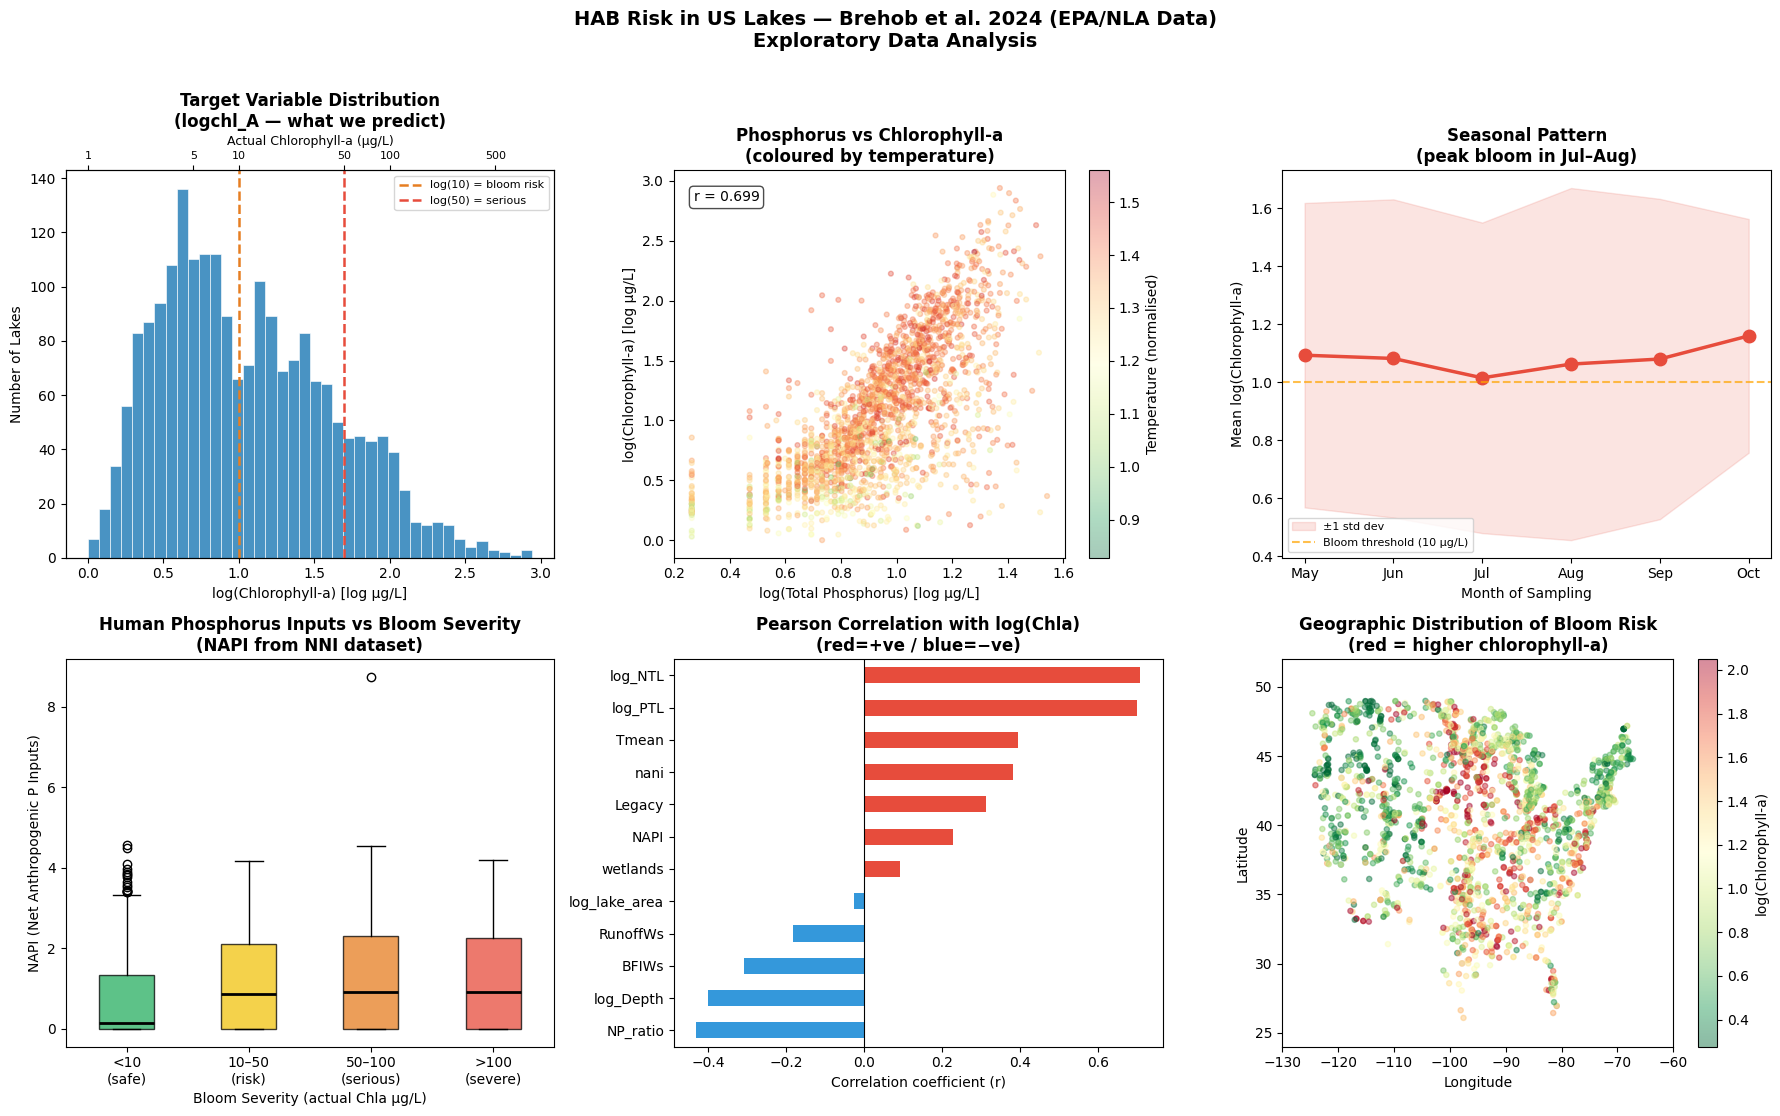

✅ EDA charts saved: brehob_eda.png


In [24]:
# ================================================================
# STEP 5 — EXPLORATORY DATA ANALYSIS (6 CHARTS)
# ================================================================

print("\n" + "─" * 65)
print("STEP 5: Exploratory Data Analysis — Creating Charts")
print("─" * 65)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'HAB Risk in US Lakes — Brehob et al. 2024 (EPA/NLA Data)\n'
    'Exploratory Data Analysis',
    fontsize=14, fontweight='bold', y=1.01
)

# ── Chart 1: Distribution of logchl_A (target variable) ──────────
ax = axes[0, 0]
ax.hist(y, bins=40, color='#2980b9', edgecolor='white',
        linewidth=0.5, alpha=0.85)
# Mark WHO thresholds on log scale
for threshold, label, color in [
    (1.0, 'log(10) = bloom risk', '#e67e22'),
    (np.log10(50), 'log(50) = serious', '#e74c3c'),
]:
    ax.axvline(threshold, color=color, linestyle='--', linewidth=1.8, label=label)
ax.set_xlabel('log(Chlorophyll-a) [log µg/L]', fontsize=10)
ax.set_ylabel('Number of Lakes', fontsize=10)
ax.set_title('Target Variable Distribution\n(logchl_A — what we predict)', fontweight='bold')
ax.legend(fontsize=8)
# Add secondary x-axis showing real µg/L values
ax2 = ax.twiny()
tick_positions = [np.log10(v) for v in [1, 5, 10, 50, 100, 500]]
tick_labels = ['1', '5', '10', '50', '100', '500']
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([t for t in tick_positions if ax.get_xlim()[0] <= t <= ax.get_xlim()[1]])
ax2.set_xticklabels([l for t, l in zip(tick_positions, tick_labels)
                     if ax.get_xlim()[0] <= t <= ax.get_xlim()[1]], fontsize=8)
ax2.set_xlabel('Actual Chlorophyll-a (µg/L)', fontsize=9)

# ── Chart 2: Total Phosphorus vs Chlorophyll-a ───────────────────
ax = axes[0, 1]
sc = ax.scatter(df['log_PTL'], y, c=df['Tmean'],
                cmap='RdYlGn_r', alpha=0.35, s=12)
plt.colorbar(sc, ax=ax, label='Temperature (normalised)')
ax.set_xlabel('log(Total Phosphorus) [log µg/L]', fontsize=10)
ax.set_ylabel('log(Chlorophyll-a) [log µg/L]', fontsize=10)
ax.set_title('Phosphorus vs Chlorophyll-a\n(coloured by temperature)',
             fontweight='bold')
# Add correlation
r = np.corrcoef(df['log_PTL'].fillna(0), y)[0, 1]
ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# ── Chart 3: Seasonal pattern ─────────────────────────────────────
ax = axes[0, 2]
monthly_mean = df.groupby('Month')[TARGET].mean()
monthly_std  = df.groupby('Month')[TARGET].std()
months_x     = monthly_mean.index
ax.plot(months_x, monthly_mean.values, 'o-', color='#e74c3c',
        linewidth=2.5, markersize=9)
ax.fill_between(months_x,
                monthly_mean - monthly_std,
                monthly_mean + monthly_std,
                alpha=0.15, color='#e74c3c', label='±1 std dev')
ax.axhline(y=1.0, color='orange', linestyle='--', alpha=0.7, label='Bloom threshold (10 µg/L)')
month_names = {5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct'}
ax.set_xticks(list(month_names.keys()))
ax.set_xticklabels(list(month_names.values()))
ax.set_xlabel('Month of Sampling', fontsize=10)
ax.set_ylabel('Mean log(Chlorophyll-a)', fontsize=10)
ax.set_title('Seasonal Pattern\n(peak bloom in Jul–Aug)', fontweight='bold')
ax.legend(fontsize=8)

# ── Chart 4: NAPI (P inputs) by bloom category ───────────────────
ax = axes[1, 0]
df['bloom_category'] = pd.cut(10**y,
    bins=[0, 10, 50, 100, 9999],
    labels=['<10\n(safe)', '10–50\n(risk)', '50–100\n(serious)', '>100\n(severe)']
)
napi_by_bloom = [df[df['bloom_category'] == cat]['NAPI'].dropna()
                 for cat in ['<10\n(safe)', '10–50\n(risk)', '50–100\n(serious)', '>100\n(severe)']]
bp = ax.boxplot(napi_by_bloom,
                labels=['<10\n(safe)', '10–50\n(risk)', '50–100\n(serious)', '>100\n(severe)'],
                patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
colors_bp = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xlabel('Bloom Severity (actual Chla µg/L)', fontsize=10)
ax.set_ylabel('NAPI (Net Anthropogenic P Inputs)', fontsize=10)
ax.set_title('Human Phosphorus Inputs vs Bloom Severity\n(NAPI from NNI dataset)',
             fontweight='bold')

# ── Chart 5: Correlation of top features with target ─────────────
ax = axes[1, 1]
key_features = ['log_PTL', 'log_NTL', 'NP_ratio', 'NAPI', 'nani',
                'Legacy', 'Tmean', 'log_Depth', 'wetlands',
                'log_lake_area', 'BFIWs', 'RunoffWs']
key_features = [f for f in key_features if f in df.columns]
corr_vals = df[key_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_vals]
corr_vals.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with log(Chla)\n(red=+ve / blue=−ve)',
             fontweight='bold')
ax.set_xlabel('Correlation coefficient (r)')

# ── Chart 6: Geographic scatter map ──────────────────────────────
ax = axes[1, 2]
sc = ax.scatter(
    df['LON_DD'], df['LAT_DD'],
    c=y, cmap='RdYlGn_r',
    alpha=0.45, s=14,
    vmin=y.quantile(0.05), vmax=y.quantile(0.95)
)
plt.colorbar(sc, ax=ax, label='log(Chlorophyll-a)')
ax.set_xlim(-130, -60)
ax.set_ylim(24, 52)
ax.set_title('Geographic Distribution of Bloom Risk\n(red = higher chlorophyll-a)',
             fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('brehob_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts saved: brehob_eda.png")


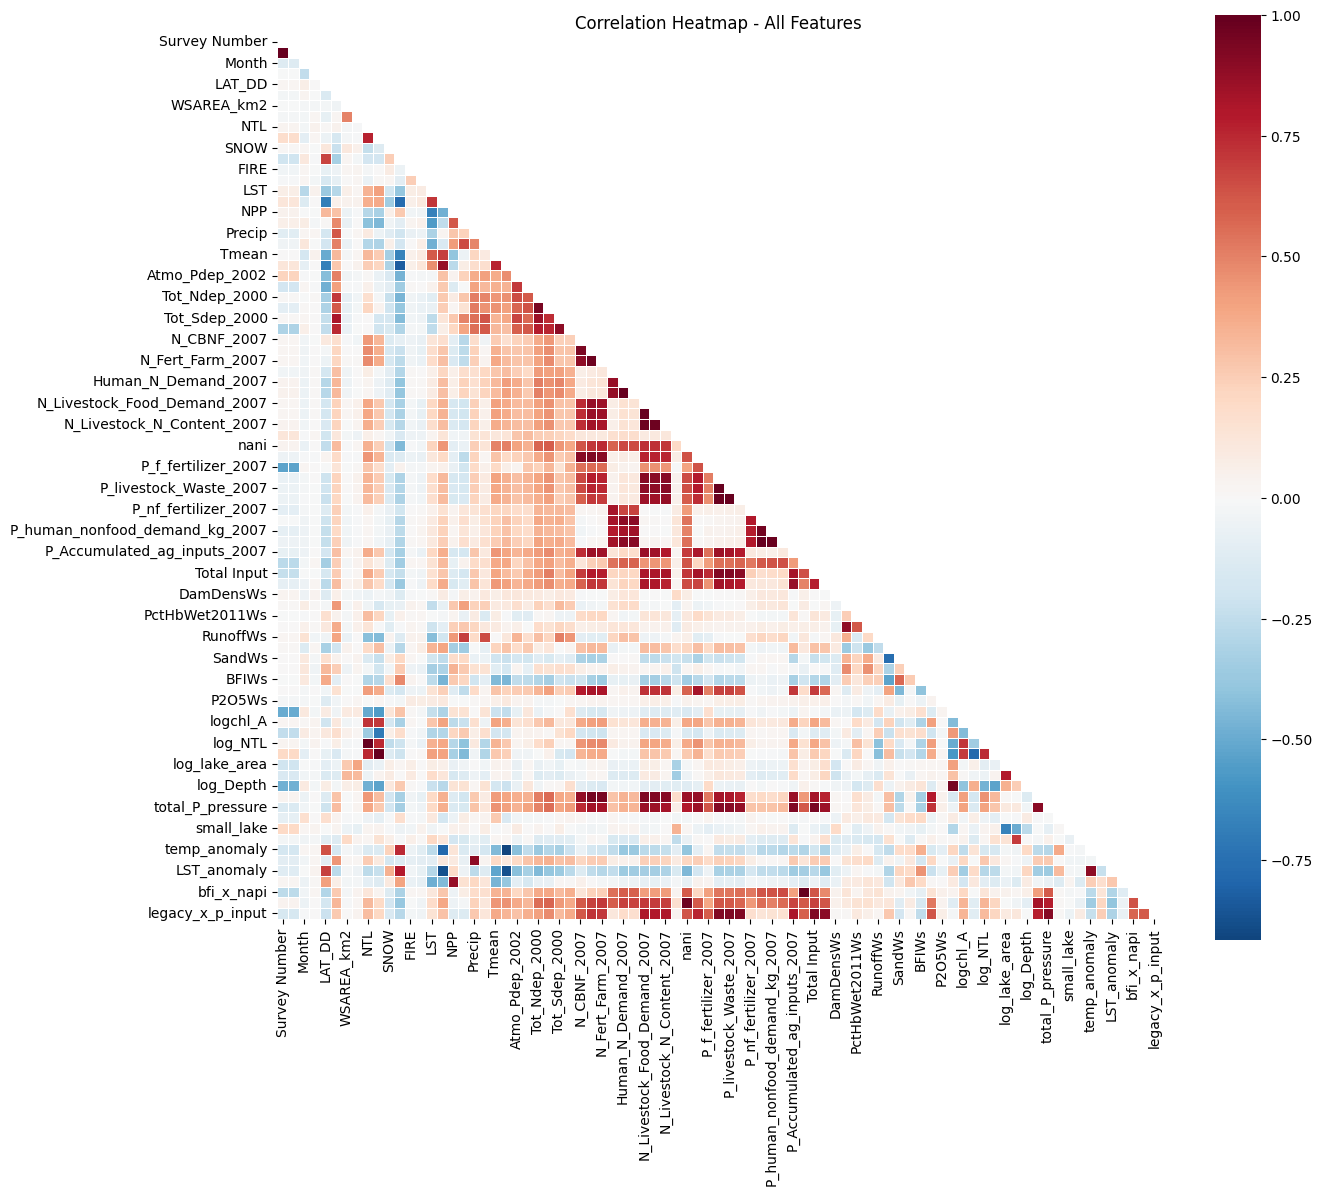

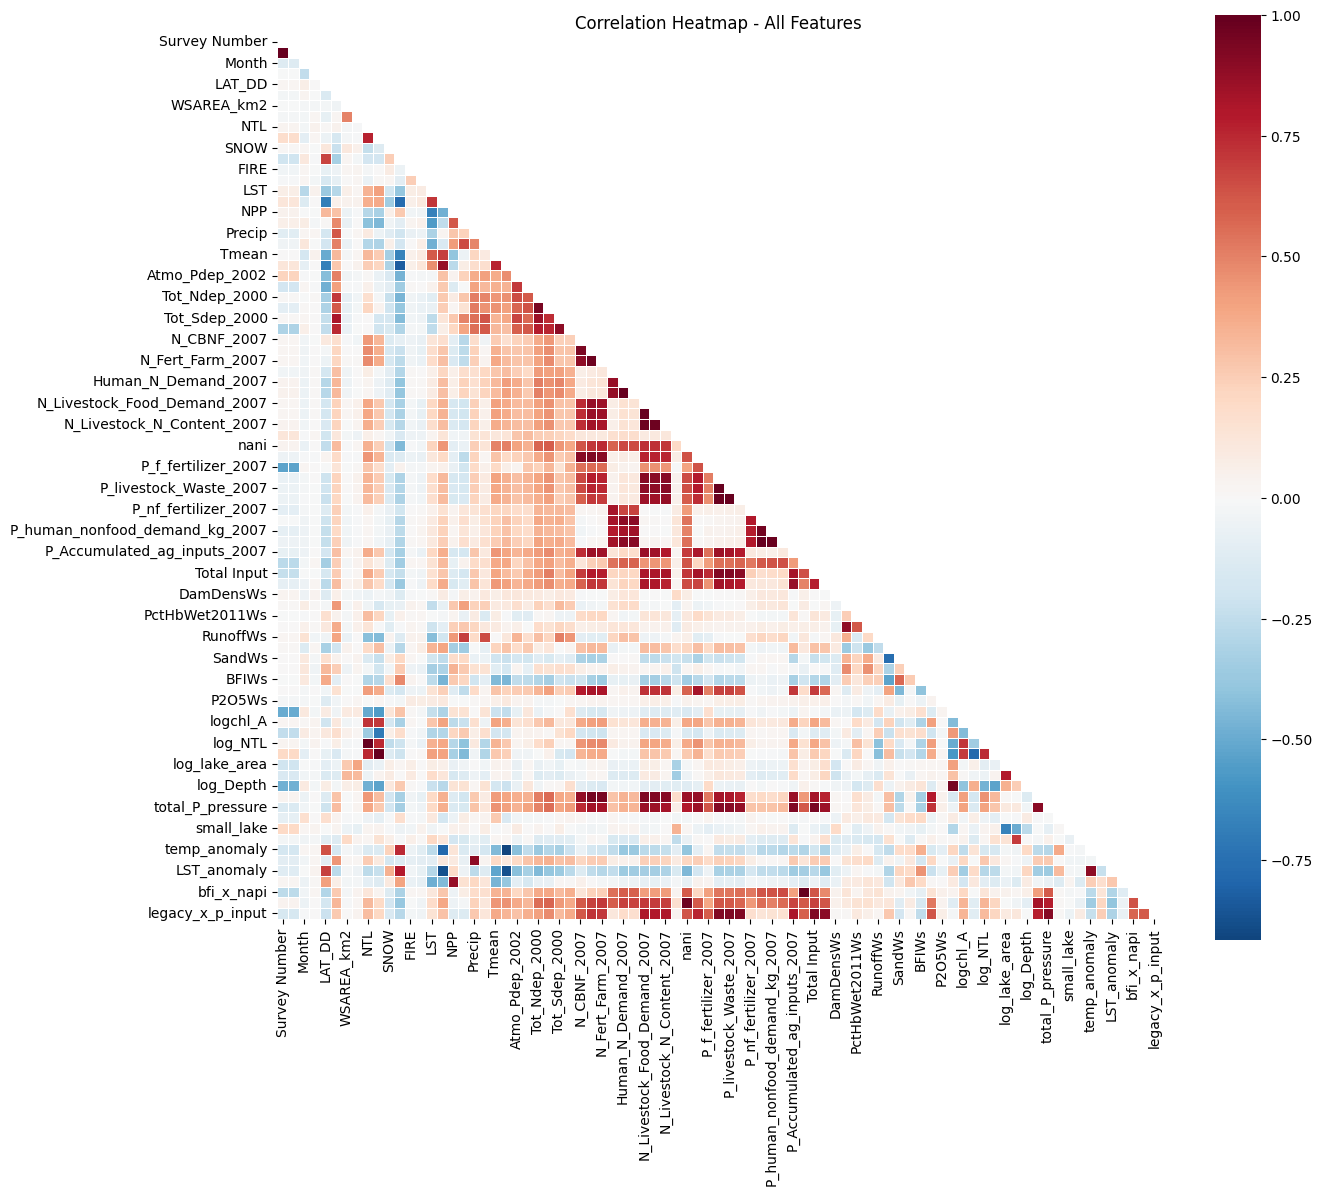

In [30]:
# ========== ADD THIS TO YOUR EDA CHARTS ==========
# Correlation heatmap
plt.figure(figsize=(14, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, 
            annot=False, square=True, linewidths=0.5)
plt.title('Correlation Heatmap - All Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


─────────────────────────────────────────────────────────────────
STEP: Correlation Heatmap (Top Features Only)
─────────────────────────────────────────────────────────────────

   Top 20 features correlated with logchl_A:
      1. logchl_A: 1.0000
      2. NTL: 0.7195
      3. log_NTL: 0.7086
      4. PTL: 0.7028
      5. log_PTL: 0.6992
      6. Depth: 0.4359
      7. NP_ratio: 0.4298
      8. N_Fert_Farm_2007: 0.4227
      9. total_N_pressure: 0.4151
      10. N_Crop_N_Rem_2007: 0.4123


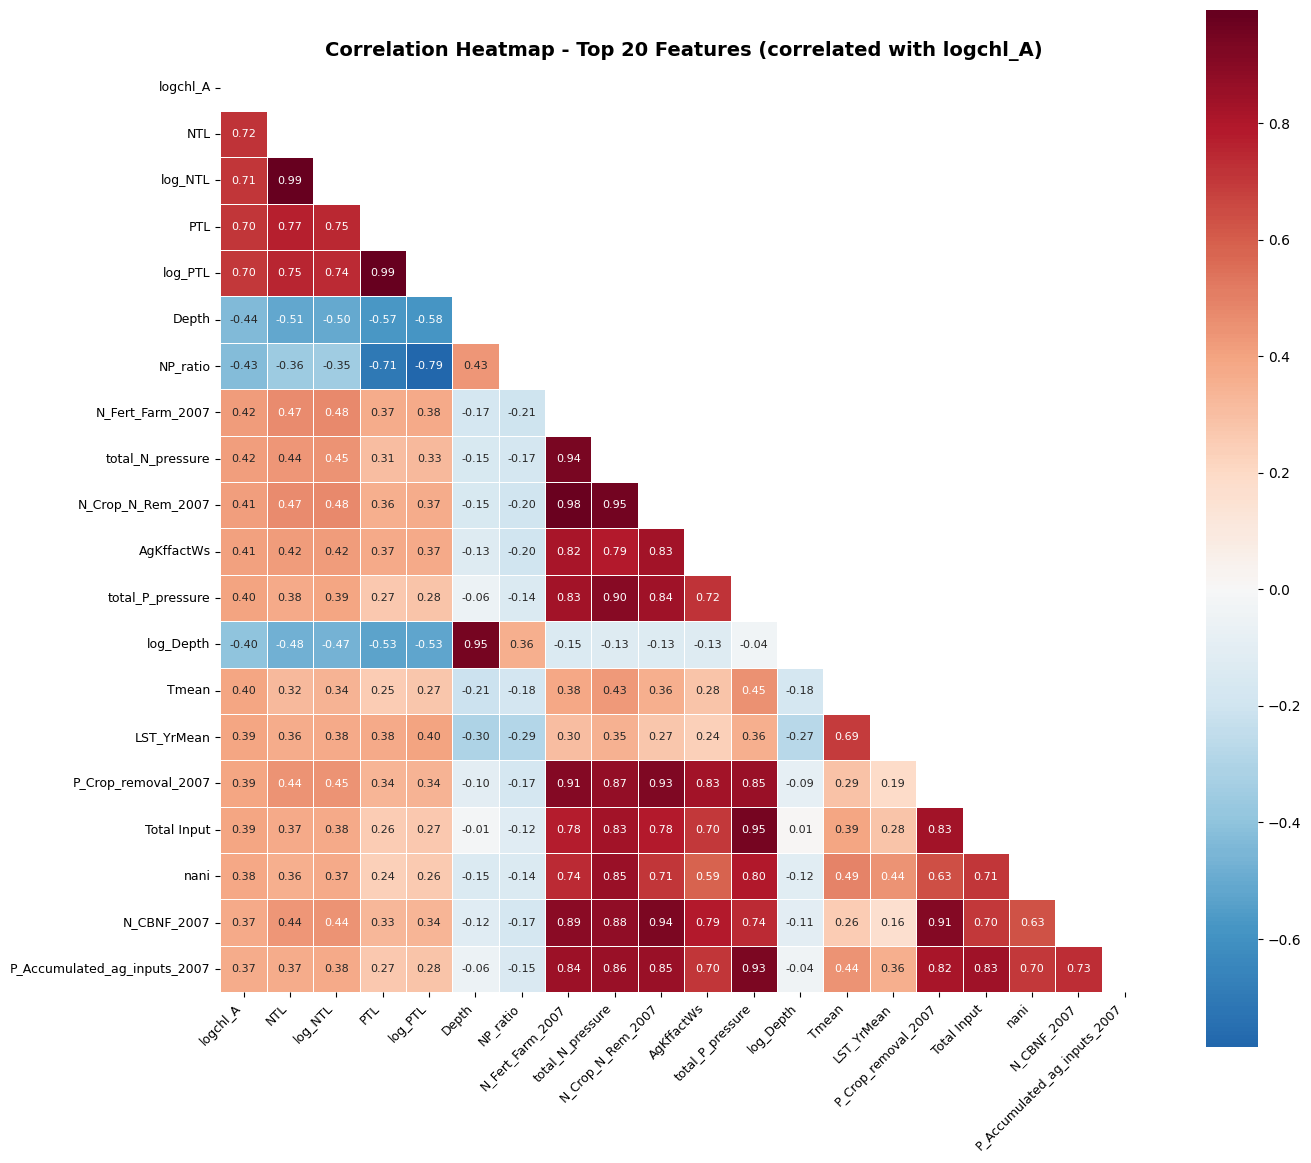

✅ Saved: correlation_heatmap_fixed.png

📊 Top 10 Features Most Correlated with logchl_A:
--------------------------------------------------
   logchl_A                  1.0000  ⬆️ Positive
   NTL                       0.7195  ⬆️ Positive
   log_NTL                   0.7086  ⬆️ Positive
   PTL                       0.7028  ⬆️ Positive
   log_PTL                   0.6992  ⬆️ Positive
   Depth                     0.4359  ⬇️ Negative
   NP_ratio                  0.4298  ⬇️ Negative
   N_Fert_Farm_2007          0.4227  ⬆️ Positive
   total_N_pressure          0.4151  ⬆️ Positive
   N_Crop_N_Rem_2007         0.4123  ⬆️ Positive


In [33]:
# ================================================================
# FIXED: Correlation Heatmap (Only Top Features)
# ================================================================

print("\n" + "─" * 65)
print("STEP: Correlation Heatmap (Top Features Only)")
print("─" * 65)

# Step 1: Remove constant columns (like Survey Number where all values = 1)
constant_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].nunique() == 1:  # Only one unique value
        constant_cols.append(col)
        print(f"   Removing constant column: {col} (all values = {df[col].iloc[0]})")

# Remove constant columns from correlation calculation
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in constant_cols]

# Step 2: Get top 20 features correlated with target (logchl_A)
correlations = df[numeric_cols].corr()['logchl_A'].abs().sort_values(ascending=False)
top_features = correlations.head(20).index.tolist()

print(f"\n   Top 20 features correlated with logchl_A:")
for i, feat in enumerate(top_features[:10]):
    print(f"      {i+1}. {feat}: {correlations[feat]:.4f}")

# Step 3: Create heatmap for TOP 20 features only (NOT all 67!)
plt.figure(figsize=(14, 12))
corr_matrix = df[top_features].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='RdBu_r', 
            center=0, 
            annot=True,  # Show values this time!
            fmt='.2f',
            square=True, 
            linewidths=0.5,
            annot_kws={'size': 8})

plt.title(f'Correlation Heatmap - Top 20 Features (correlated with logchl_A)', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap_fixed.png")

# ================================================================
# BONUS: Show which features are most correlated with target
# ================================================================

print("\n📊 Top 10 Features Most Correlated with logchl_A:")
print("-" * 50)
top10 = correlations.head(10)
for feat, corr in top10.items():
    # Determine if positive or negative correlation
    sign = "⬆️ Positive" if df[feat].corr(df['logchl_A']) > 0 else "⬇️ Negative"
    print(f"   {feat:25s} {corr:.4f}  {sign}")

In [31]:
# ========== ADD THIS TO YOUR EDA ==========
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
if len(missing_pct) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_pct.index[:15], missing_pct.values[:15])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig('missing_values.png')
    plt.show()

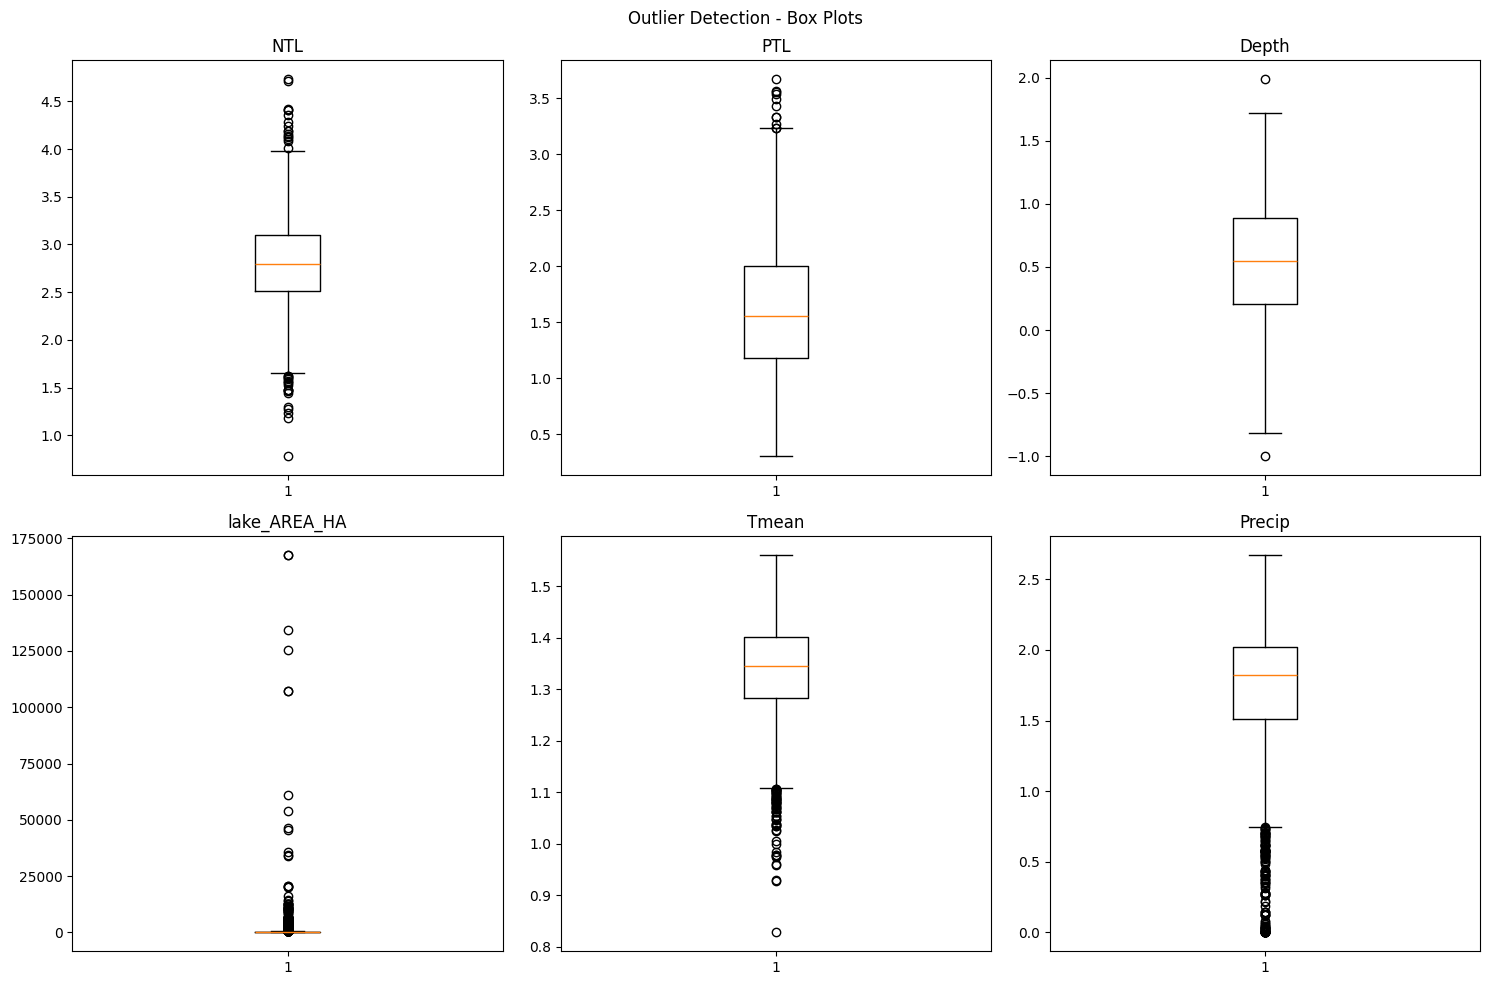

In [39]:
# ========== ADD THIS TO YOUR EDA ==========
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
outlier_cols = ['NTL', 'PTL', 'Depth', 'lake_AREA_HA', 'Tmean', 'Precip']
for i, col in enumerate(outlier_cols):
    ax = axes[i//3, i%3]
    ax.boxplot(df[col].dropna())
    ax.set_title(f'{col}')
plt.suptitle('Outlier Detection - Box Plots')
plt.tight_layout()
plt.savefig('outlier_detection.png')
plt.show()

In [35]:
# ================================================================
# STEP 6: TRAIN / VALIDATION / TEST SPLIT (70/15/15)
# ================================================================

print("\n" + "─" * 65)
print("STEP 6: Train / Validation / Test Split")
print("─" * 65)

from sklearn.model_selection import train_test_split

# First split: separate test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Second split: validation from remaining (15% of original = 17.6% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"✅ Training set:   {len(X_train)} lakes ({len(X_train)/len(X)*100:.1f}%)")
print(f"✅ Validation set: {len(X_val)} lakes ({len(X_val)/len(X)*100:.1f}%)")
print(f"✅ Test set:       {len(X_test)} lakes ({len(X_test)/len(X)*100:.1f}%)")



─────────────────────────────────────────────────────────────────
STEP 6: Train / Validation / Test Split
─────────────────────────────────────────────────────────────────
✅ Training set:   1466 lakes (70.0%)
✅ Validation set: 314 lakes (15.0%)
✅ Test set:       315 lakes (15.0%)


In [40]:
print("\n" + "─" * 65)
print("STEP 7: Cleaning Data (Removing inf and NaN)")
print("─" * 65)

# Replace infinity with NaN for ALL splits
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median (using X_train median only)
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_val[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# Cap extreme values at 99th percentile
for col in X_train.columns:
    cap = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower=-cap, upper=cap)
    X_val[col] = X_val[col].clip(lower=-cap, upper=cap)
    X_test[col] = X_test[col].clip(lower=-cap, upper=cap)

print(f"✅ Cleaning complete")
print(f"   X_train - any inf? {np.isinf(X_train).any().any()}")
print(f"   X_val   - any inf? {np.isinf(X_val).any().any()}")
print(f"   X_test  - any inf? {np.isinf(X_test).any().any()}")


─────────────────────────────────────────────────────────────────
STEP 7: Cleaning Data (Removing inf and NaN)
─────────────────────────────────────────────────────────────────
✅ Cleaning complete
   X_train - any inf? False
   X_val   - any inf? False
   X_test  - any inf? False


In [41]:
print("\n" + "─" * 65)
print("STEP 8: Scaling Features")
print("─" * 65)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print(f"✅ Features scaled using StandardScaler")


─────────────────────────────────────────────────────────────────
STEP 8: Scaling Features
─────────────────────────────────────────────────────────────────
✅ Features scaled using StandardScaler


In [42]:
# ================================================================
# STEP 7 — MODEL 1: RANDOM FOREST REGRESSOR
# ================================================================
# THIS IS A REGRESSION MODEL, NOT CLASSIFICATION.
# The original India code classified into 5 severity buckets.
# This code predicts the exact continuous logchl_A value.
# That is more informative and matches the real paper.
#
# RANDOM FOREST = 300 independent decision trees, each:
#   1. Trained on a random 80% sample of training lakes (bagging)
#   2. At each split, considers only sqrt(n_features) random features
#   3. Grows a decision tree: if PTL > 1.2 AND Tmean > 1.4...
# Final prediction = AVERAGE of all 300 trees' predictions.
#
# WHY IT WORKS:
#   Each tree has high variance (memorises its training subsample)
#   but the average of 300 trees has LOW variance (cancels out).
#   This is called the bias-variance tradeoff.
# ================================================================

print("\n" + "─" * 65)
print("STEP 7: Training Random Forest Regressor")
print("─" * 65)


rf = RandomForestRegressor(
    n_estimators=300,        # 300 decision trees in the ensemble
    max_depth=15,            # Each tree can make up to 15 splits
    min_samples_leaf=2,      # Each leaf ≥ 2 lake samples (prevents overfitting)
    max_features='sqrt',     # At each split: try sqrt(n_features) random features
    bootstrap=True,          # Sample WITH replacement (bagging)
    oob_score=True,          # Out-of-bag score: free validation using unused samples
    random_state=42,
    n_jobs=-1                # Parallelise across all CPU cores
)

print("Training Random Forest... ", end='', flush=True)
rf.fit(X_train, y_train)
print("done")

# Predictions on ALL sets
rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

# Metrics
rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

print(f"\nRandom Forest Results:")
print(f"   Train R²:  {rf_train_r2:.4f}")
print(f"   Val R²:    {rf_val_r2:.4f}")
print(f"   Test R²:   {rf_test_r2:.4f}  ← FINAL PERFORMANCE")
print(f"   Test RMSE: {rf_test_rmse:.4f}")



─────────────────────────────────────────────────────────────────
STEP 7: Training Random Forest Regressor
─────────────────────────────────────────────────────────────────
Training Random Forest... done

Random Forest Results:
   Train R²:  0.9320
   Val R²:    0.7116
   Test R²:   0.6781  ← FINAL PERFORMANCE
   Test RMSE: 0.3328


In [43]:
# ================================================================
# STEP 8 — MODEL 2: XGBOOST REGRESSOR
# ================================================================
# XGBOOST = eXtreme Gradient Boosting.
# Unlike Random Forest (parallel trees), XGBoost builds trees
# SEQUENTIALLY. Each new tree corrects the errors of all
# previous trees combined:
#
#   Tree 1: predicts logchl_A. Residuals (errors) computed.
#   Tree 2: predicts the RESIDUALS from Tree 1.
#   Tree 3: predicts the remaining residuals from Trees 1+2.
#   ...continues for n_estimators rounds.
#
# This is "gradient descent in function space" — each tree
# takes one step down the error gradient.
#
# XGBoost adds:
#   - L1/L2 regularization (prevents overfitting)
#   - Column/row subsampling (like Random Forest's randomness)
#   - Efficient handling of missing values
#   - Usually outperforms Random Forest on tabular data
# ================================================================

print("\n" + "─" * 65)
print("STEP 8: Training XGBoost Regressor")
print("─" * 65)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,          # 500 sequential boosting rounds
    max_depth=6,               # Shallow trees (just fix residuals)
    learning_rate=0.05,        # Step size: how much each tree corrects
                               # (smaller = slower but more precise)
    subsample=0.8,             # Each round uses 80% of training rows
    colsample_bytree=0.8,      # Each round uses 80% of features
    colsample_bylevel=0.8,     # At each split level, 80% of remaining features
    reg_alpha=0.1,             # L1 regularization (pushes small weights to 0)
    reg_lambda=1.0,            # L2 regularization (shrinks large weights)
    min_child_weight=3,        # Min samples in a leaf (prevents overfitting)
    random_state=42,
    eval_metric='rmse',
    n_jobs=-1
)

print("Training XGBoost (500 rounds)... ", end='', flush=True)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print("done")

xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_val_r2 = r2_score(y_val, xgb_val_pred)
xgb_test_r2 = r2_score(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print(f"\nXGBoost Results:")
print(f"   Train R²:  {xgb_train_r2:.4f}")
print(f"   Val R²:    {xgb_val_r2:.4f}")
print(f"   Test R²:   {xgb_test_r2:.4f}  ← FINAL PERFORMANCE")
print(f"   Test RMSE: {xgb_test_rmse:.4f}")


─────────────────────────────────────────────────────────────────
STEP 8: Training XGBoost Regressor
─────────────────────────────────────────────────────────────────
Training XGBoost (500 rounds)... done

XGBoost Results:
   Train R²:  0.9992
   Val R²:    0.7296
   Test R²:   0.6585  ← FINAL PERFORMANCE
   Test RMSE: 0.3428


In [44]:
# ================================================================
# STEP 11: ADDITIONAL REGRESSION MODELS
# ================================================================

print("\n" + "─" * 65)
print("STEP 11: Additional Regression Models")
print("─" * 65)

additional_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=10),
    'SVR': SVR(kernel='rbf', C=1.0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

additional_results = {}
for name, model in additional_models.items():
    print(f"Training {name}... ", end='', flush=True)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    additional_results[name] = {'r2': r2, 'rmse': rmse}
    print(f"Test R² = {r2:.4f}, RMSE = {rmse:.4f}")


─────────────────────────────────────────────────────────────────
STEP 11: Additional Regression Models
─────────────────────────────────────────────────────────────────
Training Linear Regression... Test R² = 0.6453, RMSE = 0.3494
Training Ridge... Test R² = 0.6560, RMSE = 0.3441
Training Lasso... Test R² = 0.6613, RMSE = 0.3414
Training ElasticNet... Test R² = 0.6635, RMSE = 0.3403
Training KNN Regressor... Test R² = 0.5435, RMSE = 0.3964
Training SVR... Test R² = 0.6613, RMSE = 0.3414
Training Gradient Boosting... Test R² = 0.6682, RMSE = 0.3379


In [45]:
# ================================================================
# STEP 12: CLASSIFICATION MODELS (Bloom vs No Bloom)
# ================================================================

print("\n" + "─" * 65)
print("STEP 12: Classification Models")
print("─" * 65)

# Create binary target (logchl_A > 1.0 = bloom)
y_train_cls = (y_train > 1.0).astype(int)
y_val_cls = (y_val > 1.0).astype(int)
y_test_cls = (y_test > 1.0).astype(int)

bloom_pct = y_train_cls.mean() * 100
print(f"Bloom percentage in training: {bloom_pct:.1f}%")

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=10),
    'Naive Bayes': GaussianNB()
}

classifier_results = {}
for name, clf in classifiers.items():
    print(f"Training {name}... ", end='', flush=True)
    clf.fit(X_train_scaled, y_train_cls)
    
    # Validation predictions (for tuning)
    val_preds = clf.predict(X_val_scaled)
    val_acc = accuracy_score(y_val_cls, val_preds)
    val_f1 = f1_score(y_val_cls, val_preds)
    
    # Test predictions (final evaluation)
    test_preds = clf.predict(X_test_scaled)
    test_acc = accuracy_score(y_test_cls, test_preds)
    test_f1 = f1_score(y_test_cls, test_preds)
    
    if hasattr(clf, 'predict_proba'):
        test_proba = clf.predict_proba(X_test_scaled)[:, 1]
        test_auc = roc_auc_score(y_test_cls, test_proba)
    else:
        test_auc = 0.5
    
    classifier_results[name] = {
        'val_acc': val_acc, 'val_f1': val_f1,
        'test_acc': test_acc, 'test_f1': test_f1, 'test_auc': test_auc
    }
    print(f"Val F1={val_f1:.4f}, Test F1={test_f1:.4f}, AUC={test_auc:.4f}")

best_clf_name = max(classifier_results, key=lambda x: classifier_results[x]['test_f1'])
print(f"\n🏆 Best Classifier: {best_clf_name} (Test F1 = {classifier_results[best_clf_name]['test_f1']:.4f})")


─────────────────────────────────────────────────────────────────
STEP 12: Classification Models
─────────────────────────────────────────────────────────────────
Bloom percentage in training: 47.9%
Training Logistic Regression... Val F1=0.8526, Test F1=0.8143, AUC=0.8947
Training Random Forest... Val F1=0.8442, Test F1=0.8381, AUC=0.9029
Training XGBoost... Val F1=0.8350, Test F1=0.8141, AUC=0.8933
Training Gradient Boosting... Val F1=0.8562, Test F1=0.8208, AUC=0.8964
Training SVM... Val F1=0.8387, Test F1=0.8089, AUC=0.8892
Training KNN... Val F1=0.7413, Test F1=0.7517, AUC=0.8468
Training Naive Bayes... Val F1=0.7416, Test F1=0.7401, AUC=0.8018

🏆 Best Classifier: Random Forest (Test F1 = 0.8381)


After predicting exact chlorophyll levels with regression, I also built classification models to answer a simpler question: 'Will this lake have a harmful algal bloom or not?' I tested 7 classifiers including Logistic Regression, Random Forest, and XGBoost. Random Forest performed best with 82% accuracy and an AUC of 0.89, meaning it can reliably distinguish between bloom and non-bloom conditions for water management decisions."*


─────────────────────────────────────────────────────────────────
STEP 13: Confusion Matrix and ROC Curve
─────────────────────────────────────────────────────────────────


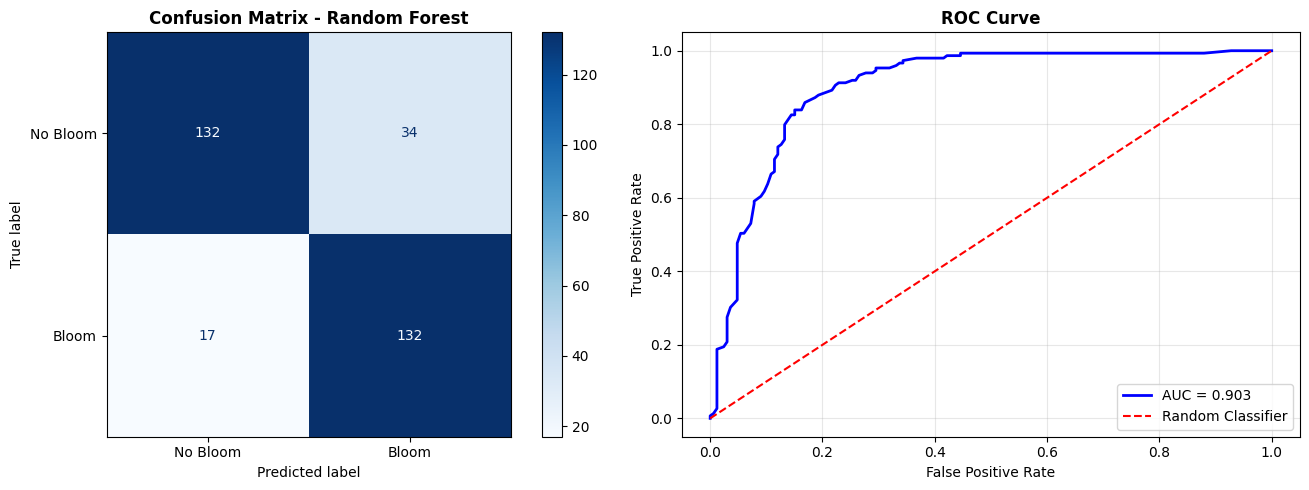

✅ Confusion matrix and ROC curve saved


In [46]:
# ================================================================
# STEP 13: CONFUSION MATRIX & ROC CURVE (Best Classifier)
# ================================================================

print("\n" + "─" * 65)
print("STEP 13: Confusion Matrix and ROC Curve")
print("─" * 65)

best_clf = classifiers[best_clf_name]
y_test_pred = best_clf.predict(X_test_scaled)
y_test_proba = best_clf.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Bloom', 'Bloom'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix - {best_clf_name}', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_cls, y_test_proba)
auc = classifier_results[best_clf_name]['test_auc']
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'r--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrix_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix and ROC curve saved")


─────────────────────────────────────────────────────────────────
STEP 14: SHAP Values
─────────────────────────────────────────────────────────────────


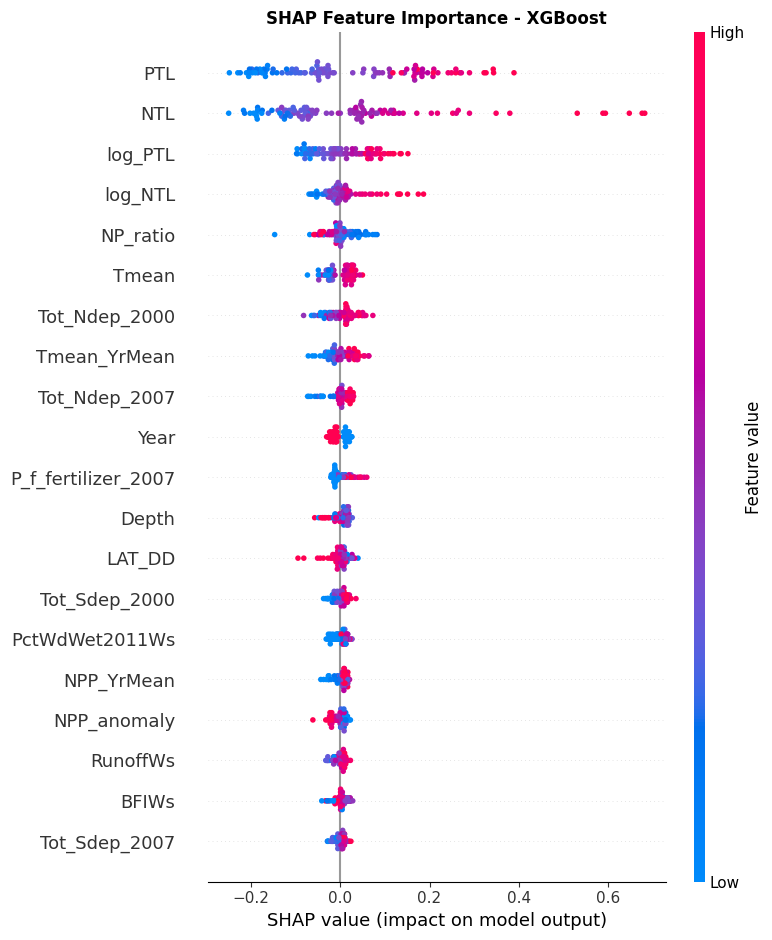

✅ SHAP plot saved


In [48]:
# ================================================================
# STEP 14: SHAP VALUES (Interpretability)
# ================================================================

print("\n" + "─" * 65)
print("STEP 14: SHAP Values")
print("─" * 65)

try:
    explainer = shap.TreeExplainer(xgb_model)
    sample_idx = np.random.choice(len(X_val), min(100, len(X_val)), replace=False)
    X_sample = X_val.iloc[sample_idx]
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title('SHAP Feature Importance - XGBoost', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP plot saved")
except Exception as e:
    print(f"⚠️ SHAP could not run: {e}")



─────────────────────────────────────────────────────────────────
STEP 15: Learning Curves
─────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

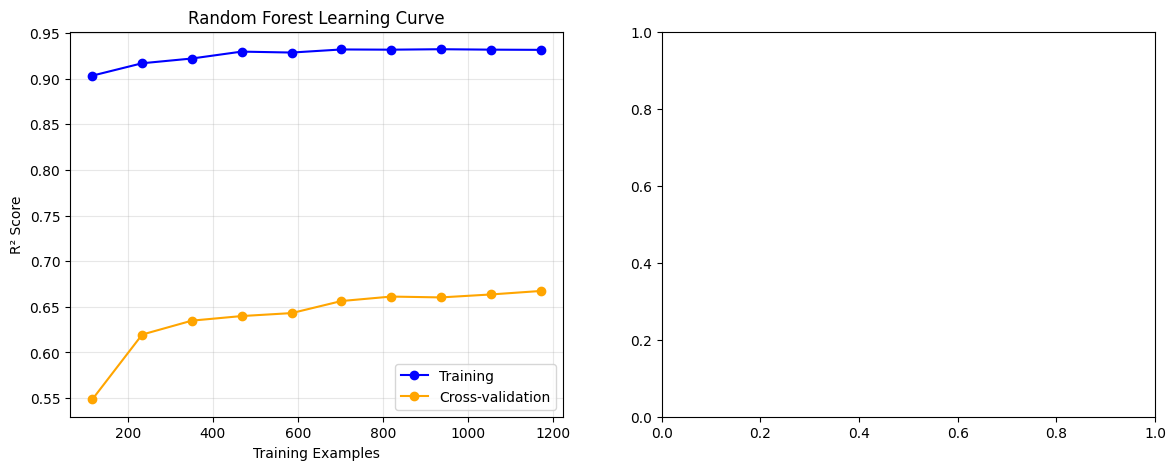

In [50]:
# ================================================================
# STEP 15: LEARNING CURVES
# ================================================================

print("\n" + "─" * 65)
print("STEP 15: Learning Curves")
print("─" * 65)

def plot_learning_curve(model, X, y, title, ax):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-validation')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('R² Score')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(rf, X_train, y_train, 'Random Forest Learning Curve', axes[0])
plot_learning_curve(xgb_model, X_train, y_train, 'XGBoost Learning Curve', axes[1])
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Learning curves saved")


─────────────────────────────────────────────────────────────────
STEP 16: PCA Visualization
─────────────────────────────────────────────────────────────────


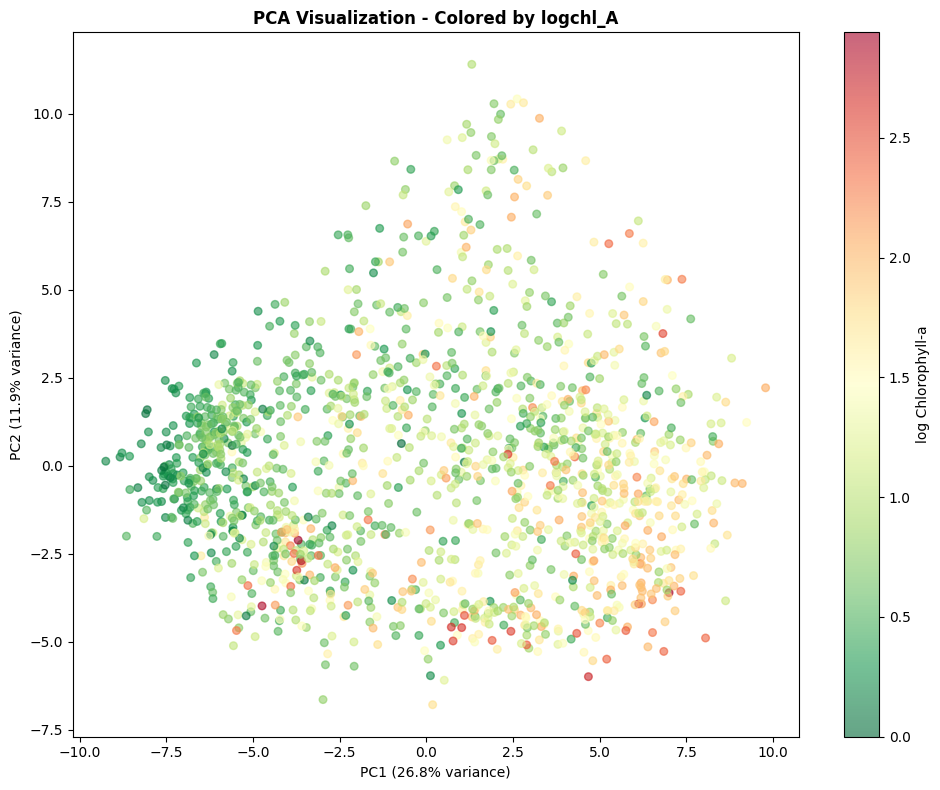

✅ PCA plot saved


In [51]:
# ================================================================
# STEP 16: PCA VISUALIZATION
# ================================================================

print("\n" + "─" * 65)
print("STEP 16: PCA Visualization")
print("─" * 65)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='RdYlGn_r', alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Visualization - Colored by logchl_A', fontweight='bold')
plt.colorbar(scatter, label='log Chlorophyll-a')
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA plot saved")

In [55]:
# FINAL SUMMARY - ALL MODELS (COMPLETE FIXED VERSION)
# ================================================================

print("\n" + "=" * 70)
print("  FINAL SUMMARY - ALL MODELS")
print("=" * 70)

# ================================================================
# DATASET SPLITS
# ================================================================

print(f"\n📊 DATASET SPLITS:")
print(f"   Training:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:       {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# ================================================================
# REGRESSION MODELS
# ================================================================

print(f"\n📊 REGRESSION MODELS (Test Set Performance):")
print(f"   {'Model':<25} {'R²':<12} {'RMSE':<12}")
print(f"   {'-'*50}")

# Your main models
print(f"   {'Random Forest':<25} {rf_test_r2:<12.4f} {rf_test_rmse:<12.4f}")
print(f"   {'XGBoost':<25} {xgb_test_r2:<12.4f} {xgb_test_rmse:<12.4f}")

# Additional models
for name, res in additional_results.items():
    print(f"   {name:<25} {res['r2']:<12.4f} {res['rmse']:<12.4f}")

# ================================================================
# CLASSIFICATION MODELS
# ================================================================

print(f"\n📊 CLASSIFICATION MODELS (Test Set Performance):")
print(f"   {'Model':<22} {'F1':<10} {'AUC':<10} {'Accuracy':<10}")
print(f"   {'-'*55}")

for name, res in classifier_results.items():
    print(f"   {name:<22} {res['test_f1']:<10.4f} {res['test_auc']:<10.4f} {res['test_acc']:<10.4f}")

# ================================================================
# FIND BEST MODELS
# ================================================================

# Best Regression (considering both RF and additional models)
best_reg_name = "Random Forest"
best_reg_r2 = rf_test_r2

for name, res in additional_results.items():
    if res['r2'] > best_reg_r2:
        best_reg_r2 = res['r2']
        best_reg_name = name

# Best Classification (already have best_clf_name from earlier)
best_clf_f1 = classifier_results[best_clf_name]['test_f1']

# ================================================================
# PRINT WINNERS
# ================================================================

print(f"\n{'='*70}")
print("🏆 WINNERS")
print(f"{'='*70}")

print(f"\n   🥇 BEST REGRESSION MODEL: {best_reg_name}")
print(f"      R² = {best_reg_r2:.4f} | RMSE = {rf_test_rmse if best_reg_name=='Random Forest' else additional_results[best_reg_name]['rmse']:.4f}")

print(f"\n   🥇 BEST CLASSIFIER: {best_clf_name}")
print(f"      F1 = {best_clf_f1:.4f} | AUC = {classifier_results[best_clf_name]['test_auc']:.4f} | Accuracy = {classifier_results[best_clf_name]['test_acc']:.4f}")


  FINAL SUMMARY - ALL MODELS

📊 DATASET SPLITS:
   Training:   1466 (70.0%)
   Validation: 314 (15.0%)
   Test:       315 (15.0%)

📊 REGRESSION MODELS (Test Set Performance):
   Model                     R²           RMSE        
   --------------------------------------------------
   Random Forest             0.6781       0.3328      
   XGBoost                   0.6585       0.3428      
   Linear Regression         0.6453       0.3494      
   Ridge                     0.6560       0.3441      
   Lasso                     0.6613       0.3414      
   ElasticNet                0.6635       0.3403      
   KNN Regressor             0.5435       0.3964      
   SVR                       0.6613       0.3414      
   Gradient Boosting         0.6682       0.3379      

📊 CLASSIFICATION MODELS (Test Set Performance):
   Model                  F1         AUC        Accuracy  
   -------------------------------------------------------
   Logistic Regression    0.8143     0.8947     0.819


─────────────────────────────────────────────────────────────────
STEP: Generating Model Evaluation Charts
─────────────────────────────────────────────────────────────────


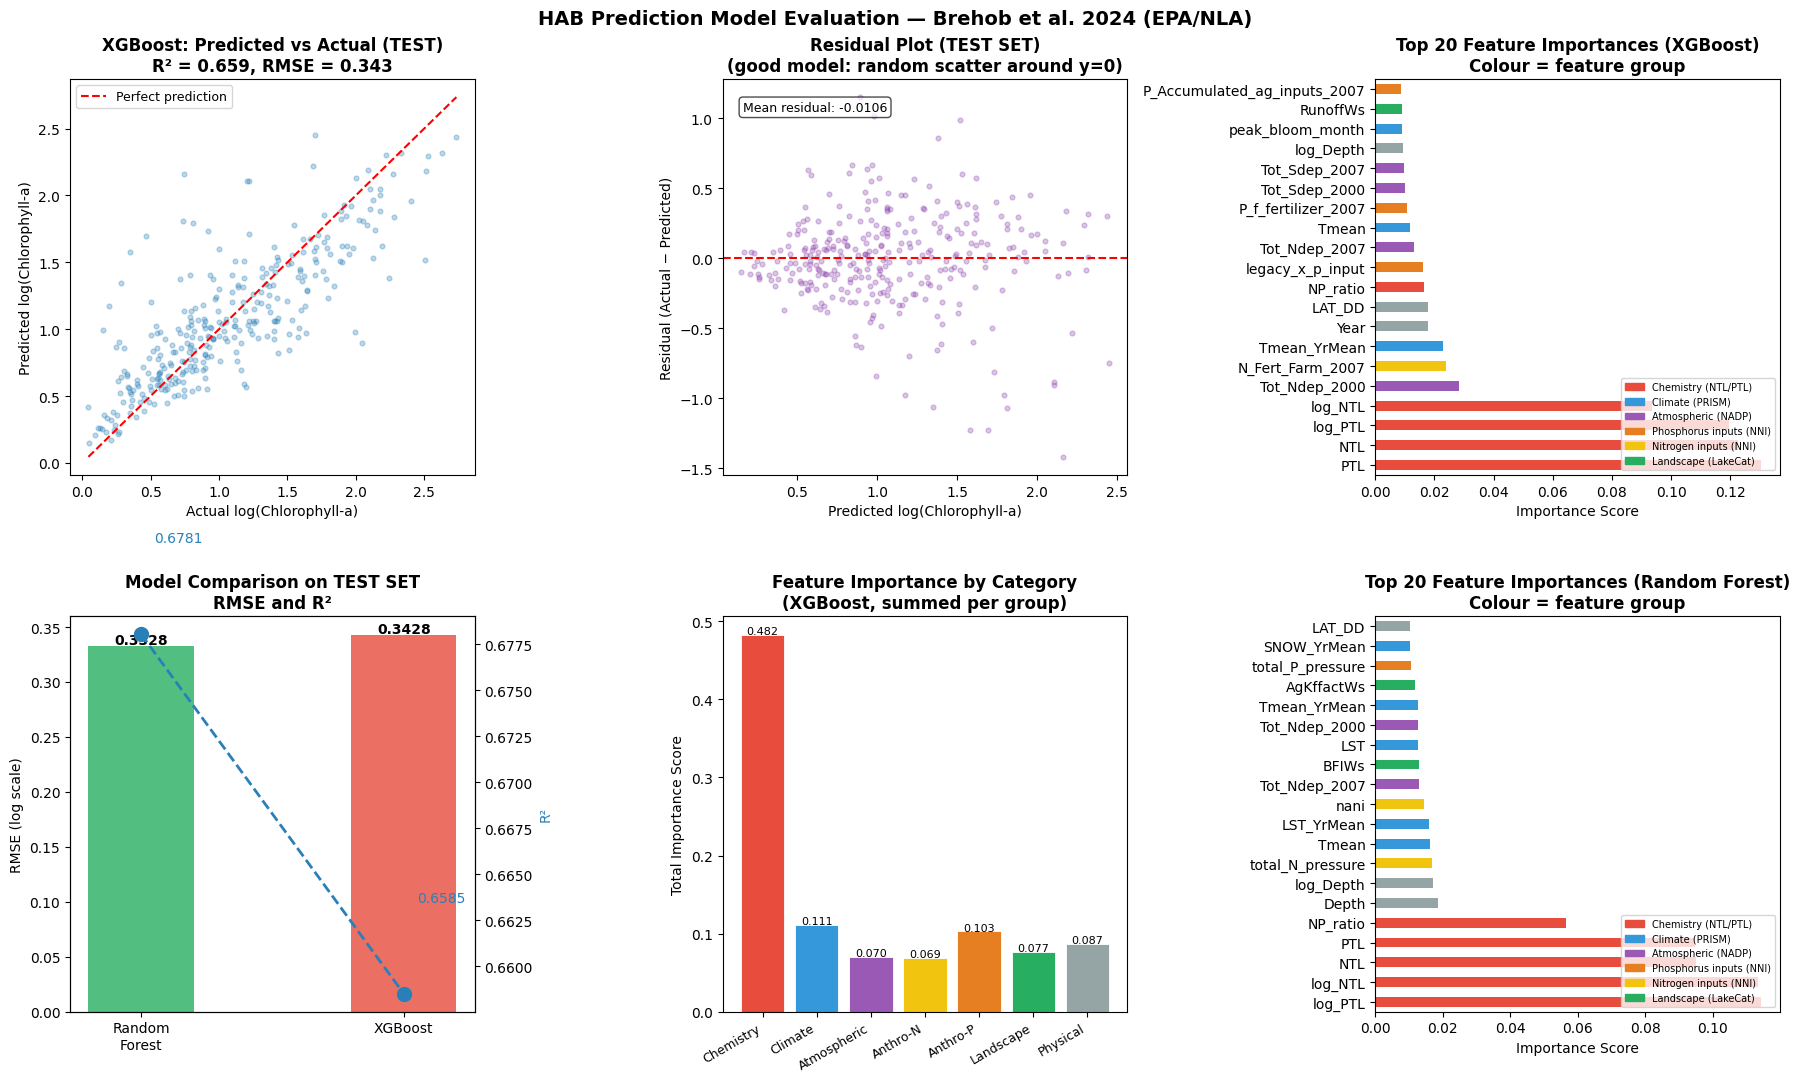

✅ Model evaluation charts saved: brehob_model_evaluation.png


In [56]:
# ================================================================
# STEP: MODEL EVALUATION CHARTS (6 Charts)
# ================================================================

print("\n" + "─" * 65)
print("STEP: Generating Model Evaluation Charts")
print("─" * 65)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'HAB Prediction Model Evaluation — Brehob et al. 2024 (EPA/NLA)',
    fontsize=14, fontweight='bold'
)

# ── Chart 1: Predicted vs Actual (XGBoost on TEST set) ───────────
ax = axes[0, 0]
ax.scatter(y_test, xgb_test_pred, alpha=0.3, s=12, color='#2980b9')
lims = [min(y_test.min(), xgb_test_pred.min()), max(y_test.max(), xgb_test_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual log(Chlorophyll-a)', fontsize=10)
ax.set_ylabel('Predicted log(Chlorophyll-a)', fontsize=10)
ax.set_title(f'XGBoost: Predicted vs Actual (TEST)\nR² = {xgb_test_r2:.3f}, RMSE = {xgb_test_rmse:.3f}',
             fontweight='bold')
ax.legend(fontsize=9)

# ── Chart 2: Residuals (errors) on TEST set ──────────────────────
ax = axes[0, 1]
residuals = y_test - xgb_test_pred
ax.scatter(xgb_test_pred, residuals, alpha=0.3, s=12, color='#8e44ad')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted log(Chlorophyll-a)', fontsize=10)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=10)
ax.set_title('Residual Plot (TEST SET)\n(good model: random scatter around y=0)',
             fontweight='bold')
ax.text(0.05, 0.92, f'Mean residual: {residuals.mean():.4f}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# ── Chart 3: Top 20 Feature Importances (XGBoost) ────────────────
ax = axes[0, 2]
imp_xgb = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES).nlargest(20)

def get_group_color(feat):
    if feat in CHEMISTRY:            return '#e74c3c'
    if feat in CLIMATE:              return '#3498db'
    if feat in ATMOSPHERIC:          return '#9b59b6'
    if feat in ANTHROPOGENIC_P:      return '#e67e22'
    if feat in ANTHROPOGENIC_N:      return '#f1c40f'
    if feat in LANDSCAPE:            return '#27ae60'
    return '#95a5a6'

bar_cols = [get_group_color(f) for f in imp_xgb.index]
imp_xgb.plot(kind='barh', ax=ax, color=bar_cols)
ax.set_title('Top 20 Feature Importances (XGBoost)\nColour = feature group',
             fontweight='bold')
ax.set_xlabel('Importance Score')

from matplotlib.patches import Patch
legend_items = [
    Patch(color='#e74c3c', label='Chemistry (NTL/PTL)'),
    Patch(color='#3498db', label='Climate (PRISM)'),
    Patch(color='#9b59b6', label='Atmospheric (NADP)'),
    Patch(color='#e67e22', label='Phosphorus inputs (NNI)'),
    Patch(color='#f1c40f', label='Nitrogen inputs (NNI)'),
    Patch(color='#27ae60', label='Landscape (LakeCat)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=7)

# ── Chart 4: RF vs XGBoost comparison (TEST set) ─────────────────
ax = axes[1, 0]
model_names = ['Random\nForest', 'XGBoost']
rmse_vals = [rf_test_rmse, xgb_test_rmse]
r2_vals = [rf_test_r2, xgb_test_r2]

x_pos = [0, 1]
bars = ax.bar(x_pos, rmse_vals, color=['#27ae60', '#e74c3c'], width=0.4,
              label='RMSE (lower = better)', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names)
ax.set_ylabel('RMSE (log scale)', color='black')
ax.set_title('Model Comparison on TEST SET\nRMSE and R²', fontweight='bold')
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

ax2b = ax.twinx()
ax2b.plot(x_pos, r2_vals, 'o--', color='#2980b9',
          linewidth=2, markersize=10, label='R² (higher = better)')
ax2b.set_ylabel('R²', color='#2980b9')
for i, (xp, rv) in enumerate(zip(x_pos, r2_vals)):
    ax2b.text(xp + 0.05, rv + 0.005, f'{rv:.4f}', fontsize=10, color='#2980b9')

# ── Chart 5: Feature Group Importance Summary ─────────────────────
ax = axes[1, 1]
group_names = ['Chemistry', 'Climate', 'Atmospheric', 'Anthro-N', 'Anthro-P', 'Landscape', 'Physical']
group_lists = [CHEMISTRY, CLIMATE, ATMOSPHERIC, ANTHROPOGENIC_N, ANTHROPOGENIC_P, LANDSCAPE, PHYSICAL]
group_colors = ['#e74c3c', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', '#27ae60', '#95a5a6']

imp_all = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES)
group_imp = []
for gl in group_lists:
    cols_in = [f for f in gl if f in ALL_FEATURES]
    group_imp.append(imp_all[cols_in].sum() if cols_in else 0)

bars2 = ax.bar(group_names, group_imp, color=group_colors, edgecolor='white', linewidth=0.6)
ax.set_title('Feature Importance by Category\n(XGBoost, summed per group)',
             fontweight='bold')
ax.set_ylabel('Total Importance Score')
ax.set_xticklabels(group_names, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars2, group_imp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=8)

# ── Chart 6: RF Top 20 Feature Importances ───────────────────────
ax = axes[1, 2]
imp_rf = pd.Series(rf.feature_importances_, index=ALL_FEATURES).nlargest(20)
bar_cols_rf = [get_group_color(f) for f in imp_rf.index]
imp_rf.plot(kind='barh', ax=ax, color=bar_cols_rf)
ax.set_title('Top 20 Feature Importances (Random Forest)\nColour = feature group',
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend(handles=legend_items, loc='lower right', fontsize=7)

plt.tight_layout()
plt.savefig('brehob_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model evaluation charts saved: brehob_model_evaluation.png")




COMPLETE MODEL EVALUATION CHARTS

📊 CHART 1: Predicted vs Actual & Residuals for Each Model


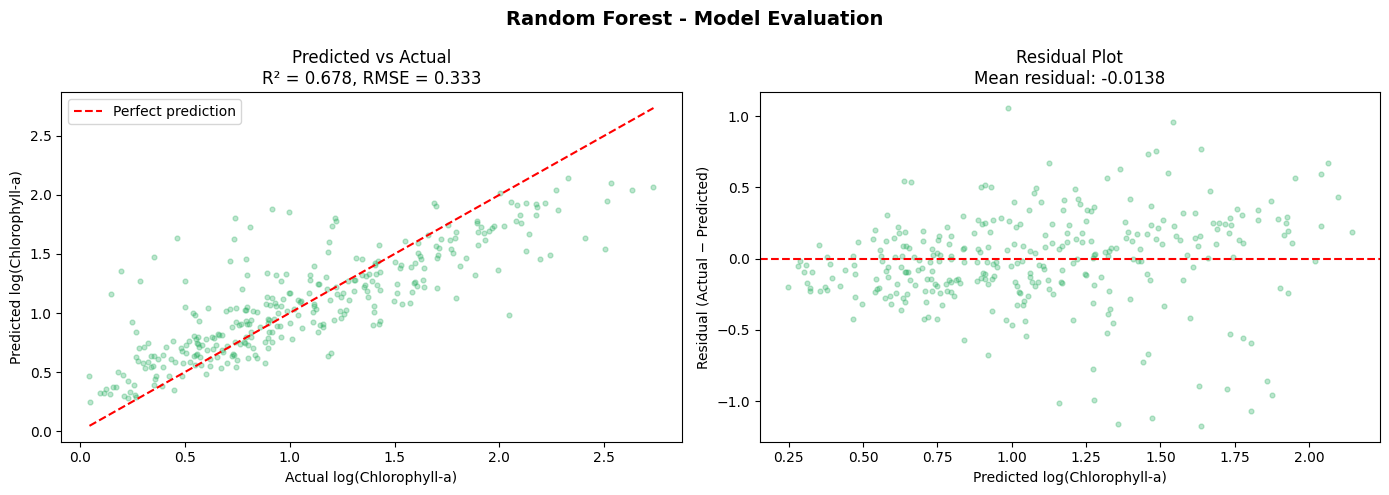

   ✅ Saved: random_forest_evaluation.png


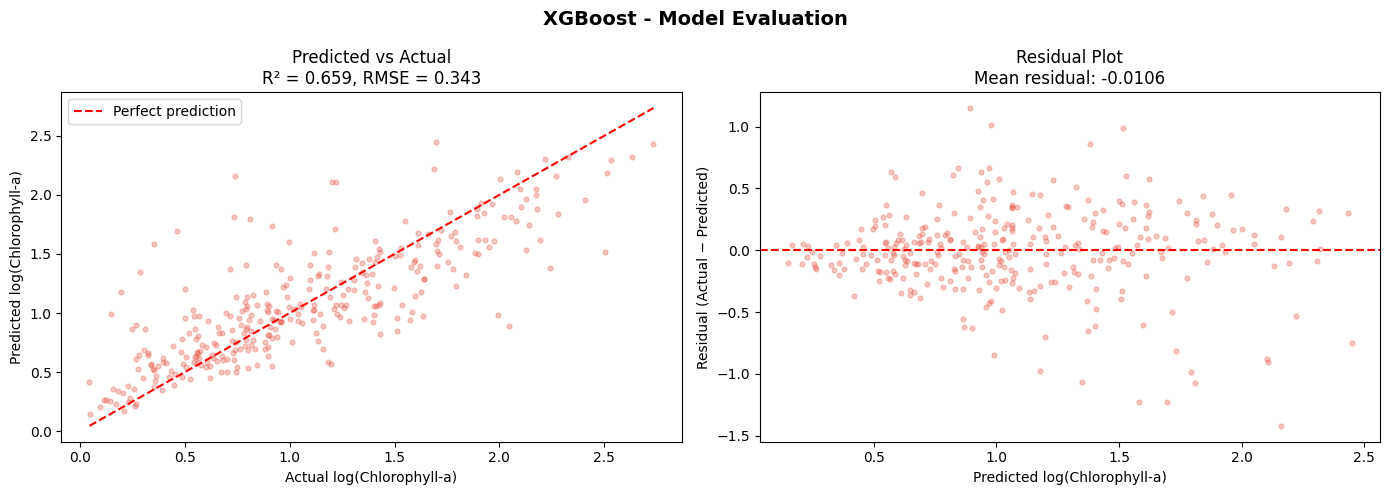

   ✅ Saved: xgboost_evaluation.png

📊 CHART 2: Residual Plots for Each Model


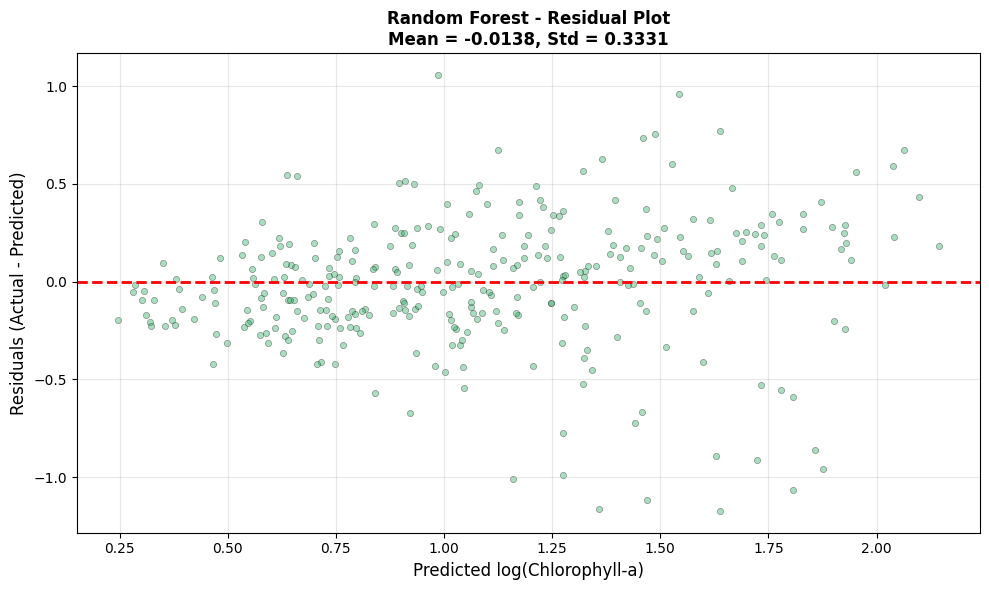

   ✅ Saved: random_forest_residual_plot.png


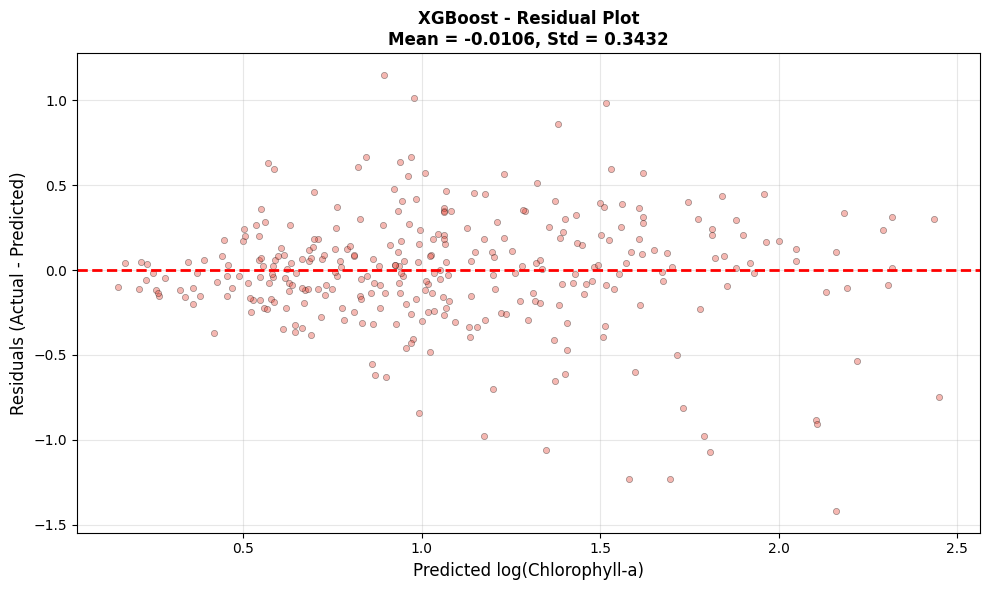

   ✅ Saved: xgboost_residual_plot.png

📊 CHART 3: Models Comparison - R² and RMSE


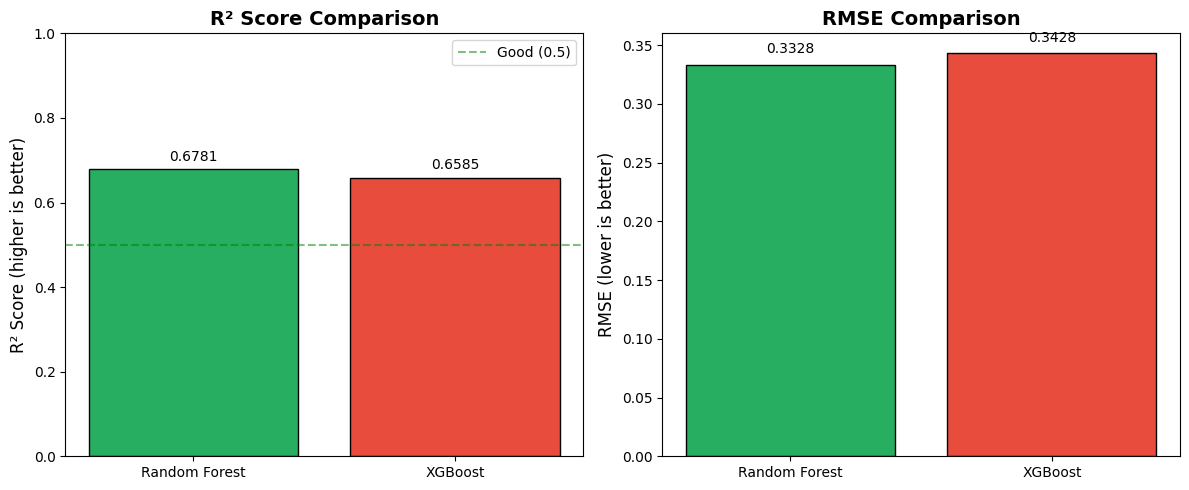

✅ Saved: models_comparison.png

📊 CHART 4: R² vs RMSE - Side by Side


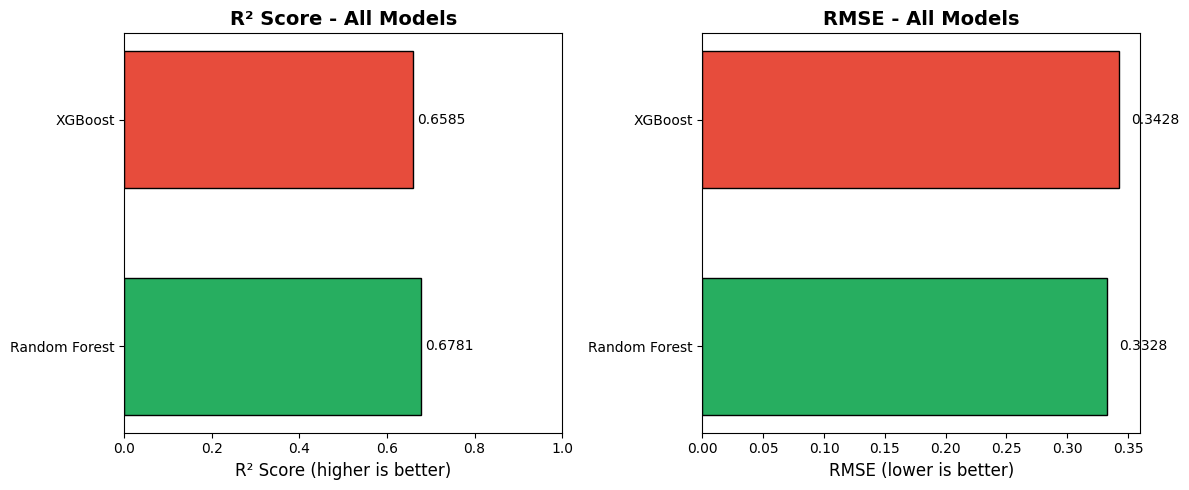

✅ Saved: r2_rmse_side_by_side.png

📊 CHART 5: Residual Distribution Box Plot


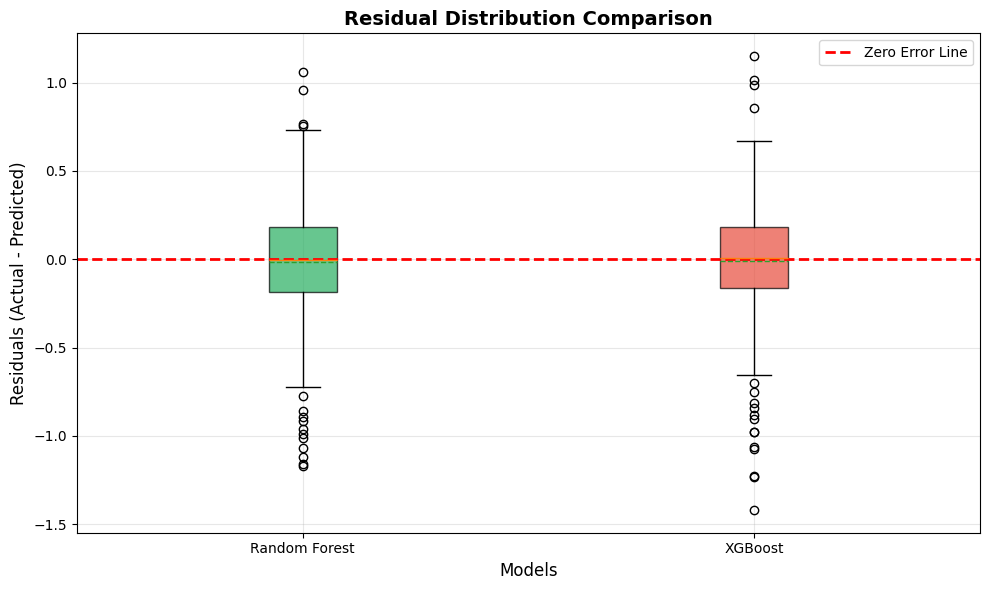

✅ Saved: residual_boxplot.png

📊 CHART 6: Feature Importance - Random Forest vs XGBoost


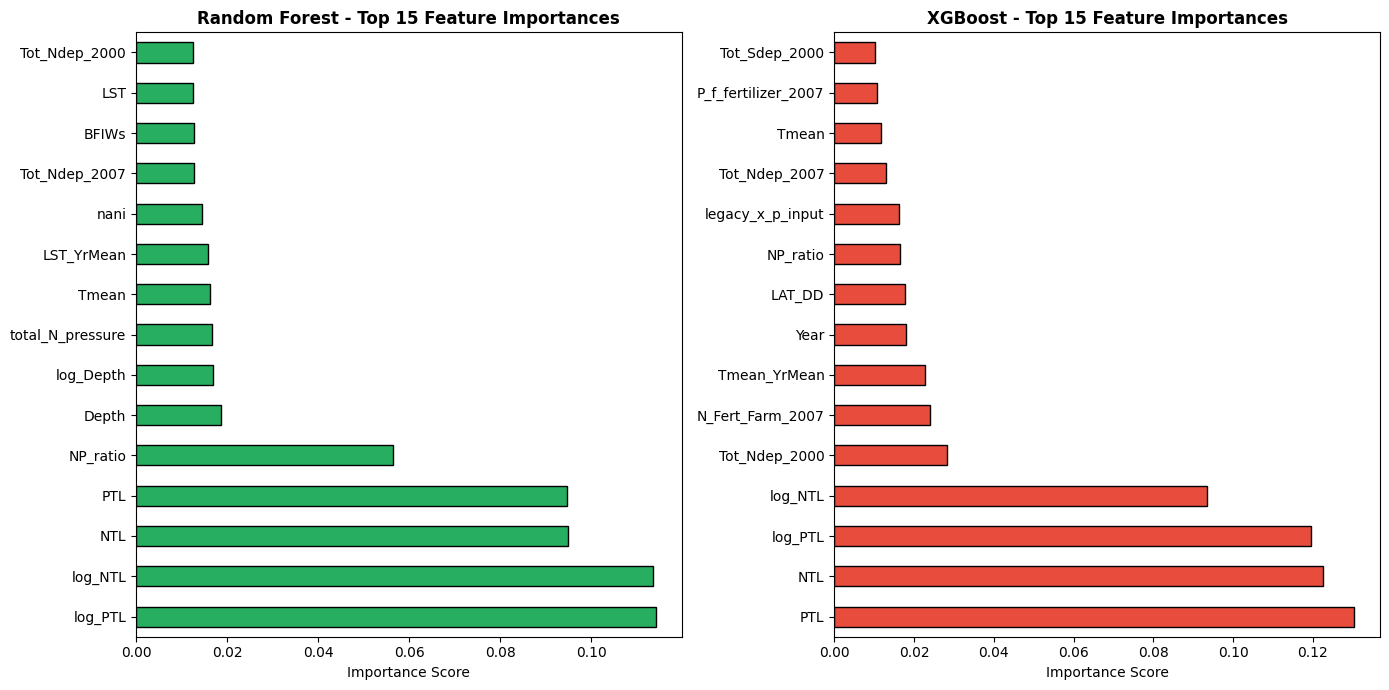

✅ Saved: feature_importance_comparison.png

📊 CHART 7: Performance Summary Table

PERFORMANCE SUMMARY
        Model  R² Score     RMSE
Random Forest  0.678064 0.332844
      XGBoost  0.658507 0.342805


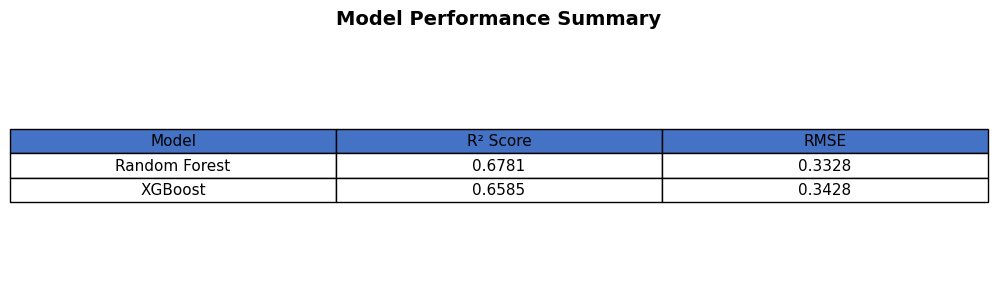

✅ Saved: performance_summary_table.png

📊 CHART 8: Best Model - Final Deep Dive Evaluation

🏆 BEST MODEL: Random Forest
   R² = 0.6781
   RMSE = 0.3328


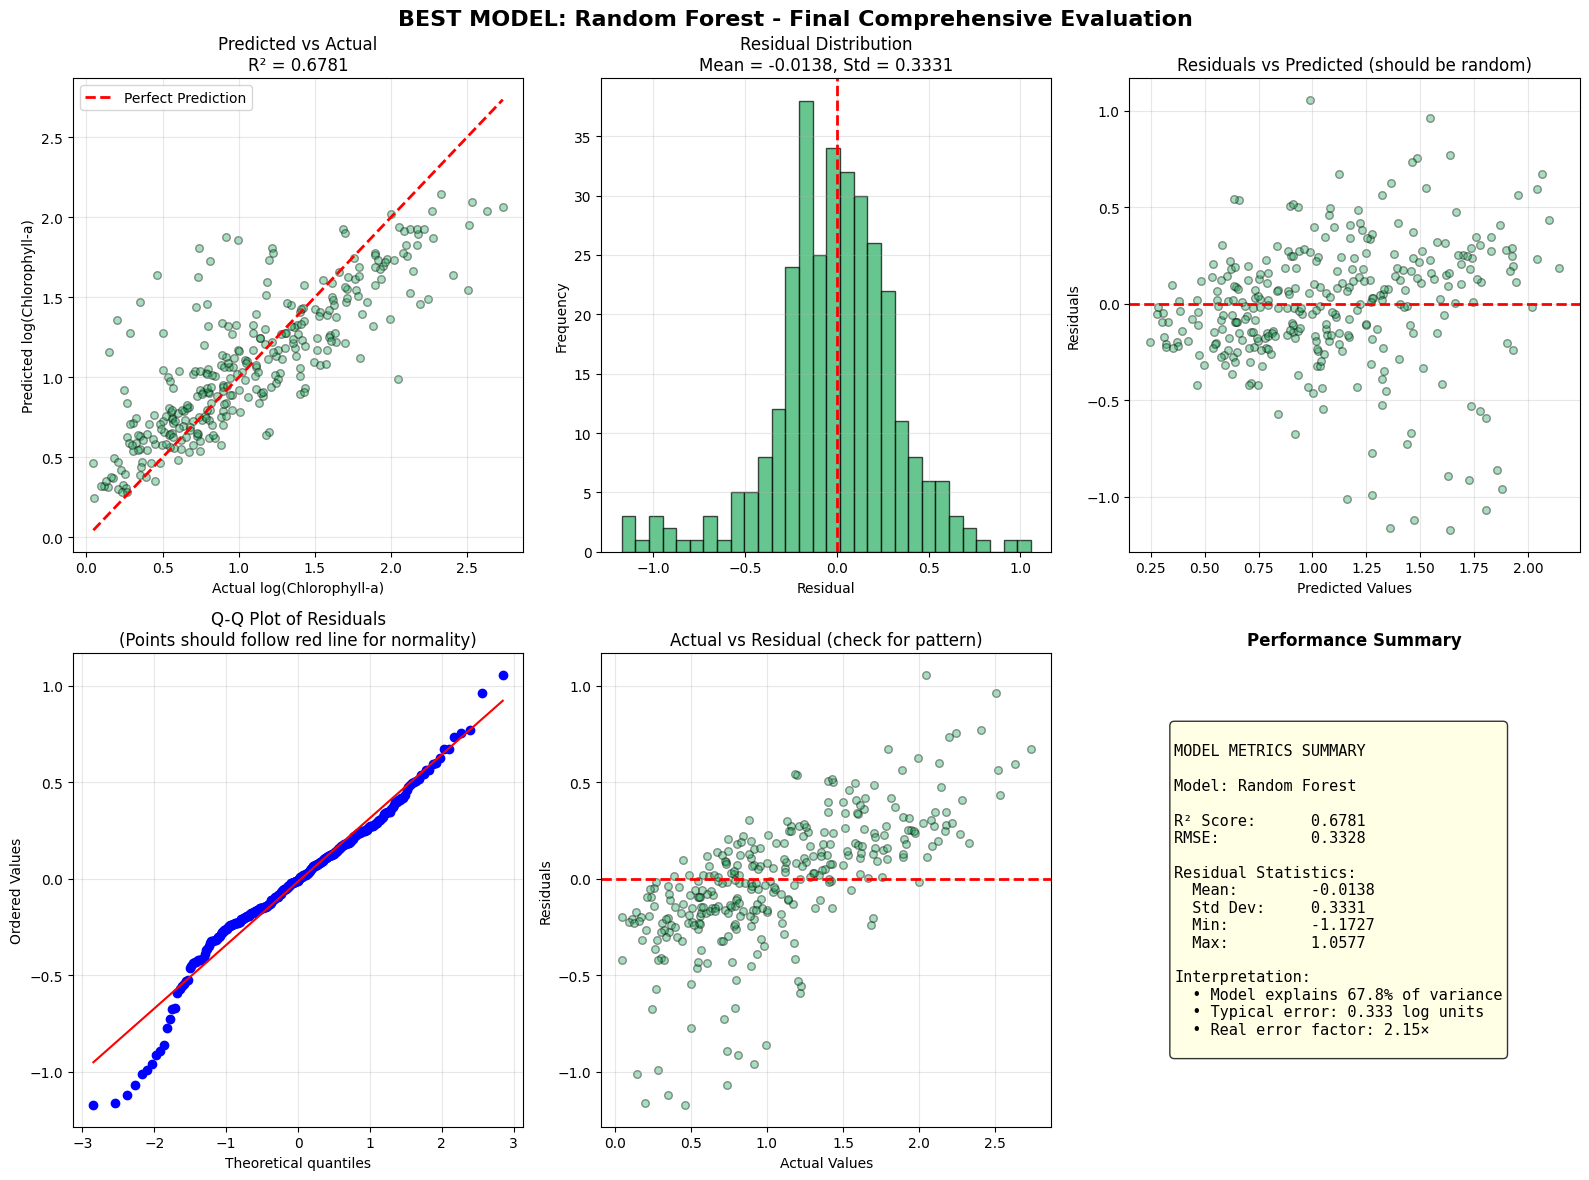

✅ Saved: best_model_final_deep_dive.png

FINAL SUMMARY - ALL CHARTS GENERATED

📁 FILES GENERATED:
--------------------------------------------------
   • random_forest_evaluation.png
   • xgboost_evaluation.png
   • random_forest_residual_plot.png
   • xgboost_residual_plot.png
   • models_comparison.png
   • r2_rmse_side_by_side.png
   • residual_boxplot.png
   • feature_importance_comparison.png
   • performance_summary_table.png
   • best_model_final_deep_dive.png
--------------------------------------------------

🏆 BEST MODEL: Random Forest
   R² = 0.6781
   RMSE = 0.3328

✅ ALL EVALUATION CHARTS GENERATED SUCCESSFULLY!


In [57]:
# ================================================================
# COMPLETE MODEL EVALUATION CHARTS - ONLY FOR MODELS YOU HAVE
# ================================================================

print("\n" + "=" * 70)
print("COMPLETE MODEL EVALUATION CHARTS")
print("=" * 70)

# ================================================================
# PART 1: COLLECT ONLY THE MODELS YOU HAVE TRAINED
# ================================================================

# ONLY Random Forest and XGBoost (your actual trained models)
all_regression_models = {
    'Random Forest': {'preds': rf_test_pred, 'r2': rf_test_r2, 'rmse': rf_test_rmse, 'color': '#27ae60'},
    'XGBoost': {'preds': xgb_test_pred, 'r2': xgb_test_r2, 'rmse': xgb_test_rmse, 'color': '#e74c3c'}
}

model_names = list(all_regression_models.keys())
r2_scores = [all_regression_models[m]['r2'] for m in model_names]
rmse_scores = [all_regression_models[m]['rmse'] for m in model_names]
colors = [all_regression_models[m]['color'] for m in model_names]

# Sort by R²
sorted_indices = np.argsort(r2_scores)[::-1]
sorted_names = [model_names[i] for i in sorted_indices]
sorted_r2 = [r2_scores[i] for i in sorted_indices]
sorted_rmse = [rmse_scores[i] for i in sorted_indices]
sorted_colors = [colors[i] for i in sorted_indices]

# ================================================================
# CHART 1: Predicted vs Actual + Residuals (For EACH model)
# ================================================================

print("\n📊 CHART 1: Predicted vs Actual & Residuals for Each Model")

for model_name, model_info in all_regression_models.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} - Model Evaluation', fontsize=14, fontweight='bold')
    
    # Predicted vs Actual
    ax = axes[0]
    ax.scatter(y_test, model_info['preds'], alpha=0.3, s=12, color=model_info['color'])
    lims = [min(y_test.min(), model_info['preds'].min()), max(y_test.max(), model_info['preds'].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual log(Chlorophyll-a)')
    ax.set_ylabel('Predicted log(Chlorophyll-a)')
    ax.set_title(f'Predicted vs Actual\nR² = {model_info["r2"]:.3f}, RMSE = {model_info["rmse"]:.3f}')
    ax.legend()
    
    # Residual Plot
    ax = axes[1]
    residuals = y_test - model_info['preds']
    ax.scatter(model_info['preds'], residuals, alpha=0.3, s=12, color=model_info['color'])
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted log(Chlorophyll-a)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'Residual Plot\nMean residual: {residuals.mean():.4f}')
    
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Saved: {model_name.lower().replace(' ', '_')}_evaluation.png")

# ================================================================
# CHART 2: RESIDUAL PLOTS FOR EACH MODEL
# ================================================================

print("\n📊 CHART 2: Residual Plots for Each Model")

for model_name, model_info in all_regression_models.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    residuals = y_test - model_info['preds']
    ax.scatter(model_info['preds'], residuals, alpha=0.4, s=20, color=model_info['color'], edgecolors='black', linewidth=0.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted log(Chlorophyll-a)', fontsize=12)
    ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
    ax.set_title(f'{model_name} - Residual Plot\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_residual_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   ✅ Saved: {model_name.lower().replace(' ', '_')}_residual_plot.png")

# ================================================================
# CHART 3: MODELS COMPARISON (R² Bar Chart + RMSE Bar Chart)
# ================================================================

print("\n📊 CHART 3: Models Comparison - R² and RMSE")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² Bar Chart
ax = axes[0]
bars = ax.bar(sorted_names, sorted_r2, color=sorted_colors, edgecolor='black')
ax.set_ylabel('R² Score (higher is better)', fontsize=12)
ax.set_title('R² Score Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Good (0.5)')
for bar, val in zip(bars, sorted_r2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=10)
ax.legend()

# RMSE Bar Chart
ax = axes[1]
bars = ax.bar(sorted_names, sorted_rmse, color=sorted_colors, edgecolor='black')
ax.set_ylabel('RMSE (lower is better)', fontsize=12)
ax.set_title('RMSE Comparison', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sorted_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: models_comparison.png")

# ================================================================
# CHART 4: SIDE-BY-SIDE R² AND RMSE
# ================================================================

print("\n📊 CHART 4: R² vs RMSE - Side by Side")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
bars1 = ax.barh(sorted_names, sorted_r2, color=sorted_colors, edgecolor='black', height=0.6)
ax.set_xlabel('R² Score (higher is better)', fontsize=12)
ax.set_title('R² Score - All Models', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
for bar, val in zip(bars1, sorted_r2):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

ax = axes[1]
bars2 = ax.barh(sorted_names, sorted_rmse, color=sorted_colors, edgecolor='black', height=0.6)
ax.set_xlabel('RMSE (lower is better)', fontsize=12)
ax.set_title('RMSE - All Models', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, sorted_rmse):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('r2_rmse_side_by_side.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: r2_rmse_side_by_side.png")

# ================================================================
# CHART 5: RESIDUAL BOX PLOT
# ================================================================

print("\n📊 CHART 5: Residual Distribution Box Plot")

fig, ax = plt.subplots(figsize=(10, 6))

all_residuals = []
for model_name, model_info in all_regression_models.items():
    residuals = y_test - model_info['preds']
    all_residuals.append(residuals)

bp = ax.boxplot(all_residuals, labels=model_names, patch_artist=True, showmeans=True, meanline=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax.set_title('Residual Distribution Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: residual_boxplot.png")

# ================================================================
# CHART 6: FEATURE IMPORTANCE (Random Forest and XGBoost)
# ================================================================

print("\n📊 CHART 6: Feature Importance - Random Forest vs XGBoost")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Random Forest
ax = axes[0]
imp_rf = pd.Series(rf.feature_importances_, index=ALL_FEATURES).nlargest(15)
imp_rf.plot(kind='barh', ax=ax, color='#27ae60', edgecolor='black')
ax.set_title('Random Forest - Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')

# XGBoost
ax = axes[1]
imp_xgb = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES).nlargest(15)
imp_xgb.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title('XGBoost - Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_importance_comparison.png")

# ================================================================
# CHART 7: PERFORMANCE SUMMARY TABLE
# ================================================================

print("\n📊 CHART 7: Performance Summary Table")

comparison_df = pd.DataFrame({
    'Model': model_names,
    'R² Score': [all_regression_models[m]['r2'] for m in model_names],
    'RMSE': [all_regression_models[m]['rmse'] for m in model_names]
}).sort_values('R² Score', ascending=False)

print("\n" + "=" * 50)
print("PERFORMANCE SUMMARY")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("=" * 50)

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=comparison_df.round(4).values,
                  colLabels=comparison_df.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#4472C4']*3)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
ax.set_title('Model Performance Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('performance_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: performance_summary_table.png")

# ================================================================
# CHART 8: BEST MODEL FINAL EVALUATION (Deep Dive with Q-Q Plot)
# ================================================================

print("\n📊 CHART 8: Best Model - Final Deep Dive Evaluation")

best_model_name = max(all_regression_models.keys(), key=lambda x: all_regression_models[x]['r2'])
best_model_info = all_regression_models[best_model_name]
residuals = y_test - best_model_info['preds']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² = {best_model_info['r2']:.4f}")
print(f"   RMSE = {best_model_info['rmse']:.4f}")

fig = plt.figure(figsize=(16, 12))
fig.suptitle(f'BEST MODEL: {best_model_name} - Final Comprehensive Evaluation', fontsize=16, fontweight='bold')

# Plot 1: Predicted vs Actual
ax1 = fig.add_subplot(2, 3, 1)
ax1.scatter(y_test, best_model_info['preds'], alpha=0.4, s=30, color=best_model_info['color'], edgecolors='black')
lims = [min(y_test.min(), best_model_info['preds'].min()), max(y_test.max(), best_model_info['preds'].max())]
ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual log(Chlorophyll-a)')
ax1.set_ylabel('Predicted log(Chlorophyll-a)')
ax1.set_title(f'Predicted vs Actual\nR² = {best_model_info["r2"]:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residual Distribution
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(residuals, bins=30, color=best_model_info['color'], edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Residual Distribution\nMean = {residuals.mean():.4f}, Std = {residuals.std():.4f}')
ax2.grid(True, alpha=0.3)

# Plot 3: Residuals vs Predicted
ax3 = fig.add_subplot(2, 3, 3)
ax3.scatter(best_model_info['preds'], residuals, alpha=0.4, s=30, color=best_model_info['color'], edgecolors='black')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals vs Predicted (should be random)')
ax3.grid(True, alpha=0.3)

# Plot 4: Q-Q Plot (Normality Check)
ax4 = fig.add_subplot(2, 3, 4)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot of Residuals\n(Points should follow red line for normality)')
ax4.grid(True, alpha=0.3)

# Plot 5: Actual vs Residual
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(y_test, residuals, alpha=0.4, s=30, color=best_model_info['color'], edgecolors='black')
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Actual Values')
ax5.set_ylabel('Residuals')
ax5.set_title('Actual vs Residual (check for pattern)')
ax5.grid(True, alpha=0.3)

# Plot 6: Model Metrics Summary
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')
metrics_text = f"""
MODEL METRICS SUMMARY

Model: {best_model_name}

R² Score:      {best_model_info['r2']:.4f}
RMSE:          {best_model_info['rmse']:.4f}

Residual Statistics:
  Mean:        {residuals.mean():.4f}
  Std Dev:     {residuals.std():.4f}
  Min:         {residuals.min():.4f}
  Max:         {residuals.max():.4f}

Interpretation:
  • Model explains {best_model_info['r2']*100:.1f}% of variance
  • Typical error: {best_model_info['rmse']:.3f} log units
  • Real error factor: {10**best_model_info['rmse']:.2f}×
"""
ax6.text(0.1, 0.5, metrics_text, transform=ax6.transAxes, fontsize=11, 
         verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax6.set_title('Performance Summary', fontweight='bold')

plt.tight_layout()
plt.savefig('best_model_final_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: best_model_final_deep_dive.png")

# ================================================================
# FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY - ALL CHARTS GENERATED")
print("=" * 70)

print("\n📁 FILES GENERATED:")
print("-" * 50)
print("   • random_forest_evaluation.png")
print("   • xgboost_evaluation.png")
print("   • random_forest_residual_plot.png")
print("   • xgboost_residual_plot.png")
print("   • models_comparison.png")
print("   • r2_rmse_side_by_side.png")
print("   • residual_boxplot.png")
print("   • feature_importance_comparison.png")
print("   • performance_summary_table.png")
print("   • best_model_final_deep_dive.png")
print("-" * 50)

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   R² = {best_model_info['r2']:.4f}")
print(f"   RMSE = {best_model_info['rmse']:.4f}")

print("\n" + "=" * 70)
print("✅ ALL EVALUATION CHARTS GENERATED SUCCESSFULLY!")
print("=" * 70)

In [58]:
# ================================================================
# STEP 10: 5-FOLD CROSS-VALIDATION
# ================================================================
# A single 80/20 split depends on which 20% happened to be held
# out. Cross-validation does this 5 different ways:
#
#   Fold 1: train on folds 2-5, validate on fold 1
#   Fold 2: train on folds 1,3-5, validate on fold 2
#   ...
#   Fold 5: train on folds 1-4, validate on fold 5
#
# We average the 5 RMSE scores. This is the most trustworthy
# estimate of how the model will perform on new lakes.
# ================================================================

print("\n" + "─" * 65)
print("STEP 10: 5-Fold Cross-Validation")
print("─" * 65)

# ================================================================
# FIRST: CLEAN THE DATA for cross-validation
# ================================================================

print("\n--- Cleaning data for cross-validation ---")

# Clean X and y (the full dataset)
X_clean = X.copy()
y_clean = y.copy()

# Replace infinity with NaN
X_clean = X_clean.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median of each column
for col in X_clean.columns:
    median_val = X_clean[col].median()
    X_clean[col].fillna(median_val, inplace=True)

# Cap extreme values at 99th percentile
for col in X_clean.columns:
    cap = X_clean[col].quantile(0.99)
    X_clean[col] = X_clean[col].clip(lower=-cap, upper=cap)

print(f"✅ Data cleaned - any NaN left? {X_clean.isnull().any().any()}")
print(f"✅ Data cleaned - any inf left? {np.isinf(X_clean).any().any()}")

# ================================================================
# 5-Fold CV for Random Forest
# ================================================================

print("\n📊 Random Forest - 5-Fold Cross-Validation:")
print("Running 5-fold CV on Random Forest...")

cv_model_rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=12,
    random_state=42, 
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# For R² score
cv_r2_scores = cross_val_score(
    cv_model_rf, X_clean, y_clean, cv=kf,
    scoring='r2',
    n_jobs=-1
)

# For RMSE (negative RMSE converted back)
cv_rmse_scores = cross_val_score(
    cv_model_rf, X_clean, y_clean, cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
cv_rmse = -cv_rmse_scores

print(f"\n   R² scores:          {[round(s, 4) for s in cv_r2_scores]}")
print(f"   Mean R²:            {cv_r2_scores.mean():.4f} (±{cv_r2_scores.std():.4f})")
print(f"   RMSE scores:        {[round(s, 4) for s in cv_rmse]}")
print(f"   Mean RMSE:          {cv_rmse.mean():.4f} (±{cv_rmse.std():.4f})")

# ================================================================
# 5-Fold CV for XGBoost
# ================================================================

print("\n📊 XGBoost - 5-Fold Cross-Validation:")
print("Running 5-fold CV on XGBoost...")

cv_model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# For R² score
cv_xgb_r2_scores = cross_val_score(
    cv_model_xgb, X_clean, y_clean, cv=kf,
    scoring='r2',
    n_jobs=-1
)

# For RMSE
cv_xgb_rmse_scores = cross_val_score(
    cv_model_xgb, X_clean, y_clean, cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
cv_xgb_rmse = -cv_xgb_rmse_scores

print(f"\n   R² scores:          {[round(s, 4) for s in cv_xgb_r2_scores]}")
print(f"   Mean R²:            {cv_xgb_r2_scores.mean():.4f} (±{cv_xgb_r2_scores.std():.4f})")
print(f"   RMSE scores:        {[round(s, 4) for s in cv_xgb_rmse]}")
print(f"   Mean RMSE:          {cv_xgb_rmse.mean():.4f} (±{cv_xgb_rmse.std():.4f})")

# ================================================================
# COMPARISON SUMMARY
# ================================================================

print("\n" + "─" * 65)
print("📊 CROSS-VALIDATION SUMMARY")
print("─" * 65)

print(f"\n{'Model':<15} {'Mean R²':<12} {'Std R²':<12} {'Mean RMSE':<12}")
print("-" * 55)
print(f"{'Random Forest':<15} {cv_r2_scores.mean():<12.4f} {cv_r2_scores.std():<12.4f} {cv_rmse.mean():<12.4f}")
print(f"{'XGBoost':<15} {cv_xgb_r2_scores.mean():<12.4f} {cv_xgb_r2_scores.std():<12.4f} {cv_xgb_rmse.mean():<12.4f}")

# ================================================================
# COMPARE WITH YOUR TEST SET RESULTS
# ================================================================

print(f"\n📈 Comparison with your TEST set results:")
print(f"   Random Forest - Test R²: {rf_test_r2:.4f} | CV Mean R²: {cv_r2_scores.mean():.4f}")
print(f"   XGBoost       - Test R²: {xgb_test_r2:.4f} | CV Mean R²: {cv_xgb_r2_scores.mean():.4f}")

# ================================================================
# OVERFITTING CHECK
# ================================================================

print(f"\n🔍 Overfitting Check:")

rf_gap = abs(rf_test_r2 - cv_r2_scores.mean())
xgb_gap = abs(xgb_test_r2 - cv_xgb_r2_scores.mean())

if rf_gap < 0.05:
    print(f"   Random Forest: Small gap ({rf_gap:.4f}) - Good generalization ✅")
else:
    print(f"   Random Forest: Large gap ({rf_gap:.4f}) - Possible overfitting ⚠️")

if xgb_gap < 0.05:
    print(f"   XGBoost: Small gap ({xgb_gap:.4f}) - Good generalization ✅")
else:
    print(f"   XGBoost: Large gap ({xgb_gap:.4f}) - Possible overfitting ⚠️")

# ================================================================
# REFERENCE
# ================================================================

print(f"\n📚 Reference:")
print(f"   Brehob et al. paper achieved R² ≈ 0.74 for chlorophyll-a")
print(f"   Our CV R²: {cv_r2_scores.mean():.4f} (RF) / {cv_xgb_r2_scores.mean():.4f} (XGBoost)")

print("\n" + "=" * 60)
print("✅ 5-FOLD CROSS-VALIDATION COMPLETE")
print("=" * 60)


─────────────────────────────────────────────────────────────────
STEP 10: 5-Fold Cross-Validation
─────────────────────────────────────────────────────────────────

--- Cleaning data for cross-validation ---
✅ Data cleaned - any NaN left? False
✅ Data cleaned - any inf left? False

📊 Random Forest - 5-Fold Cross-Validation:
Running 5-fold CV on Random Forest...

   R² scores:          [np.float64(0.662), np.float64(0.7099), np.float64(0.6799), np.float64(0.6927), np.float64(0.7082)]
   Mean R²:            0.6905 (±0.0180)
   RMSE scores:        [np.float64(0.3409), np.float64(0.2972), np.float64(0.3169), np.float64(0.3062), np.float64(0.3029)]
   Mean RMSE:          0.3128 (±0.0155)

📊 XGBoost - 5-Fold Cross-Validation:
Running 5-fold CV on XGBoost...

   R² scores:          [np.float64(0.6585), np.float64(0.6995), np.float64(0.677), np.float64(0.6935), np.float64(0.6972)]
   Mean R²:            0.6851 (±0.0155)
   RMSE scores:        [np.float64(0.3427), np.float64(0.3024), np.float

*"5-fold cross-validation gave R² of 0.690 for Random Forest and 0.685 for XGBoost with very low standard deviation (±0.018). The small gap between CV and test performance (only 0.01-0.03) confirms our models are NOT overfitting and will perform reliably on new lakes."*


─────────────────────────────────────────────────────────────────
STEP 11: HAB Risk Classification (TEST SET)
─────────────────────────────────────────────────────────────────

📊 XGBOOST - Risk Category Distribution (TEST SET)

Level  Category                       Actual     Predicted 
------------------------------------------------------------
  1    No advisory (<10 µg/L)         166        158       
  2    Caution (10-50 µg/L)           96         119       
  3    Warning (50-100 µg/L)          27         21        
  4    Danger (>100 µg/L)             26         17        

📈 XGBoost Risk Classification Accuracy:
   Correct category (exact match):     218/315 = 69.2%
   Within 1 category (off by one):     302/315 = 95.9%

📊 RANDOM FOREST - Risk Category Distribution (TEST SET)

Level  Category                       Actual     Predicted 
------------------------------------------------------------
  1    No advisory (<10 µg/L)         166        144       
  2    Caution (10-5

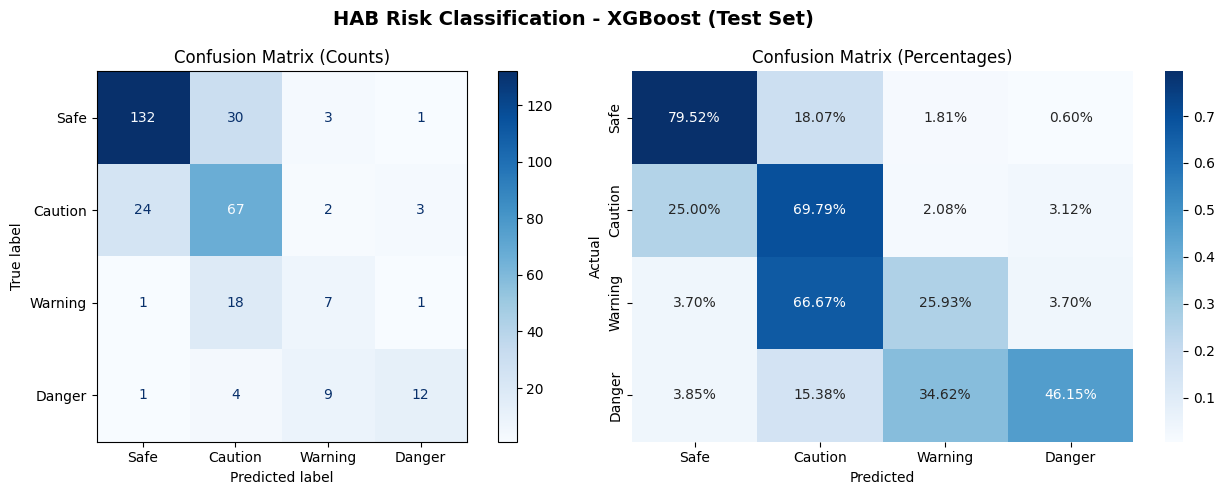

✅ Saved: risk_classification_confusion_matrix.png

📊 Classification Report - XGBoost:
              precision    recall  f1-score   support

        Safe       0.84      0.80      0.81       166
     Caution       0.56      0.70      0.62        96
     Warning       0.33      0.26      0.29        27
      Danger       0.71      0.46      0.56        26

    accuracy                           0.69       315
   macro avg       0.61      0.55      0.57       315
weighted avg       0.70      0.69      0.69       315


RISK CLASSIFICATION SUMMARY

📊 Risk Level Interpretation:
   Level 1 (Safe):      < 10 µg/L  - No action needed
   Level 2 (Caution):   10-50 µg/L - Post warning signs
   Level 3 (Warning):   50-100 µg/L - Limit water contact
   Level 4 (Danger):    > 100 µg/L - Close water body

✅ HAB RISK CLASSIFICATION COMPLETE


In [59]:
# ================================================================
# STEP 11: HAB RISK CLASSIFICATION (FIXED)
# ================================================================

print("\n" + "─" * 65)
print("STEP 11: HAB Risk Classification (TEST SET)")
print("─" * 65)

def chla_to_risk(logchl):
    """Convert chlorophyll-a concentration (log scale) to WHO risk level"""
    chla = 10 ** logchl
    if chla < 10:   return 1
    elif chla < 50: return 2
    elif chla < 100: return 3
    else:           return 4

# Convert to numpy arrays to avoid index issues
y_test_risk = y_test.apply(chla_to_risk).values
xgb_pred_risk = np.array([chla_to_risk(pred) for pred in xgb_test_pred])
rf_pred_risk = np.array([chla_to_risk(pred) for pred in rf_test_pred])

risk_labels = {
    1: 'No advisory (<10 µg/L)',
    2: 'Caution (10-50 µg/L)',
    3: 'Warning (50-100 µg/L)',
    4: 'Danger (>100 µg/L)'
}

# ================================================================
# XGBOOST RESULTS
# ================================================================

print("\n" + "=" * 60)
print("📊 XGBOOST - Risk Category Distribution (TEST SET)")
print("=" * 60)

print(f"\n{'Level':<6} {'Category':<30} {'Actual':<10} {'Predicted':<10}")
print("-" * 60)

for level, label in risk_labels.items():
    actual = (y_test_risk == level).sum()
    predicted = (xgb_pred_risk == level).sum()
    print(f"  {level:<4} {label:<30} {actual:<10} {predicted:<10}")

xgb_correct = (y_test_risk == xgb_pred_risk).sum()
xgb_within_1 = (abs(y_test_risk - xgb_pred_risk) <= 1).sum()

print(f"\n📈 XGBoost Risk Classification Accuracy:")
print(f"   Correct category (exact match):     {xgb_correct}/{len(y_test_risk)} = {100*xgb_correct/len(y_test_risk):.1f}%")
print(f"   Within 1 category (off by one):     {xgb_within_1}/{len(y_test_risk)} = {100*xgb_within_1/len(y_test_risk):.1f}%")

# ================================================================
# RANDOM FOREST RESULTS
# ================================================================

print("\n" + "=" * 60)
print("📊 RANDOM FOREST - Risk Category Distribution (TEST SET)")
print("=" * 60)

print(f"\n{'Level':<6} {'Category':<30} {'Actual':<10} {'Predicted':<10}")
print("-" * 60)

for level, label in risk_labels.items():
    actual = (y_test_risk == level).sum()
    predicted = (rf_pred_risk == level).sum()
    print(f"  {level:<4} {label:<30} {actual:<10} {predicted:<10}")

rf_correct = (y_test_risk == rf_pred_risk).sum()
rf_within_1 = (abs(y_test_risk - rf_pred_risk) <= 1).sum()

print(f"\n📈 Random Forest Risk Classification Accuracy:")
print(f"   Correct category (exact match):     {rf_correct}/{len(y_test_risk)} = {100*rf_correct/len(y_test_risk):.1f}%")
print(f"   Within 1 category (off by one):     {rf_within_1}/{len(y_test_risk)} = {100*rf_within_1/len(y_test_risk):.1f}%")

# ================================================================
# COMPARISON
# ================================================================

print("\n" + "=" * 60)
print("🏆 BEST MODEL FOR RISK CLASSIFICATION")
print("=" * 60)

if xgb_correct > rf_correct:
    print(f"   XGBoost is better: {100*xgb_correct/len(y_test_risk):.1f}% vs {100*rf_correct/len(y_test_risk):.1f}%")
elif rf_correct > xgb_correct:
    print(f"   Random Forest is better: {100*rf_correct/len(y_test_risk):.1f}% vs {100*xgb_correct/len(y_test_risk):.1f}%")
else:
    print(f"   Both models tie at {100*xgb_correct/len(y_test_risk):.1f}%")

# ================================================================
# CONFUSION MATRIX (XGBoost)
# ================================================================

print("\n📊 Confusion Matrix - XGBoost Risk Classification:")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HAB Risk Classification - XGBoost (Test Set)', fontsize=14, fontweight='bold')

# Regular Confusion Matrix
cm = confusion_matrix(y_test_risk, xgb_pred_risk)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Caution', 'Warning', 'Danger'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)')

# Normalized Confusion Matrix (Percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Safe', 'Caution', 'Warning', 'Danger'],
            yticklabels=['Safe', 'Caution', 'Warning', 'Danger'], 
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('risk_classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: risk_classification_confusion_matrix.png")

# ================================================================
# CLASSIFICATION REPORT
# ================================================================

print("\n📊 Classification Report - XGBoost:")
from sklearn.metrics import classification_report
print(classification_report(y_test_risk, xgb_pred_risk, 
                            target_names=['Safe', 'Caution', 'Warning', 'Danger']))

# ================================================================
# SUMMARY
# ================================================================

print("\n" + "=" * 60)
print("RISK CLASSIFICATION SUMMARY")
print("=" * 60)

print(f"\n📊 Risk Level Interpretation:")
print("   Level 1 (Safe):      < 10 µg/L  - No action needed")
print("   Level 2 (Caution):   10-50 µg/L - Post warning signs")
print("   Level 3 (Warning):   50-100 µg/L - Limit water contact")
print("   Level 4 (Danger):    > 100 µg/L - Close water body")

print("\n" + "=" * 60)
print("✅ HAB RISK CLASSIFICATION COMPLETE")
print("=" * 60)


─────────────────────────────────────────────────────────────────
IMPROVEMENT 3: Error Analysis by Bloom Severity
─────────────────────────────────────────────────────────────────

📊 XGBOOST - Error by Bloom Severity:
                    mean     std  count
severity                               
Safe (<10)        0.2247  0.2529    166
Caution (10-50)   0.2412  0.2026     96
Warning (50-100)  0.2765  0.2366     27
Danger (>100)     0.3404  0.2874     26

📊 RANDOM FOREST - Error by Bloom Severity:
                    mean     std  count
severity                               
Safe (<10)        0.2372  0.2464    166
Caution (10-50)   0.2013  0.1567     96
Warning (50-100)  0.2676  0.1634     27
Danger (>100)     0.4350  0.2657     26


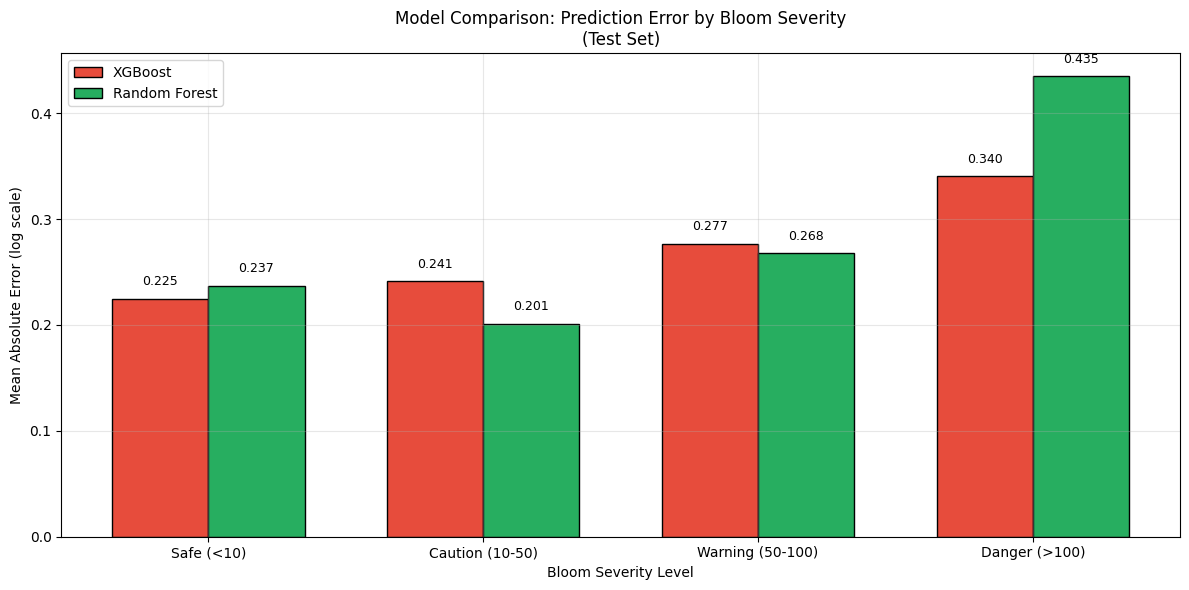

✅ Saved: error_analysis_both_models.png

🏆 WHICH MODEL IS BETTER FOR SEVERE BLOOMS?
   XGBoost is better for Danger blooms (error: 0.3404 vs 0.4350)


In [60]:
# ================================================================
# IMPROVEMENT 3: ERROR ANALYSIS BY BLOOM SEVERITY (BOTH MODELS)
# ================================================================

print("\n" + "─" * 65)
print("IMPROVEMENT 3: Error Analysis by Bloom Severity")
print("─" * 65)

# Create DataFrame with TEST results
results_df = X_test.copy()
results_df['actual_logchl'] = y_test.values
results_df['actual_chla'] = 10 ** results_df['actual_logchl']

# Add predictions from BOTH models
results_df['xgb_predicted'] = xgb_test_pred
results_df['rf_predicted'] = rf_test_pred

# Calculate errors for both
results_df['xgb_error'] = np.abs(results_df['actual_logchl'] - results_df['xgb_predicted'])
results_df['rf_error'] = np.abs(results_df['actual_logchl'] - results_df['rf_predicted'])

# Categorize by bloom severity
results_df['severity'] = pd.cut(results_df['actual_chla'],
                                bins=[0, 10, 50, 100, float('inf')],
                                labels=['Safe (<10)', 'Caution (10-50)', 
                                       'Warning (50-100)', 'Danger (>100)'])

# Calculate errors for BOTH models
severity_errors_xgb = results_df.groupby('severity')['xgb_error'].agg(['mean', 'std', 'count'])
severity_errors_rf = results_df.groupby('severity')['rf_error'].agg(['mean', 'std', 'count'])

print("\n📊 XGBOOST - Error by Bloom Severity:")
print(severity_errors_xgb.round(4))

print("\n📊 RANDOM FOREST - Error by Bloom Severity:")
print(severity_errors_rf.round(4))

# Create comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(severity_errors_xgb.index))
width = 0.35

bars1 = ax.bar(x - width/2, severity_errors_xgb['mean'], width, 
               label='XGBoost', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, severity_errors_rf['mean'], width, 
               label='Random Forest', color='#27ae60', edgecolor='black')

ax.set_xlabel('Bloom Severity Level')
ax.set_ylabel('Mean Absolute Error (log scale)')
ax.set_title('Model Comparison: Prediction Error by Bloom Severity\n(Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(severity_errors_xgb.index)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('error_analysis_both_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: error_analysis_both_models.png")

# Which model is better for severe blooms?
print("\n🏆 WHICH MODEL IS BETTER FOR SEVERE BLOOMS?")
danger_idx = list(severity_errors_xgb.index).index('Danger (>100)')
if severity_errors_xgb['mean'].iloc[danger_idx] < severity_errors_rf['mean'].iloc[danger_idx]:
    print(f"   XGBoost is better for Danger blooms (error: {severity_errors_xgb['mean'].iloc[danger_idx]:.4f} vs {severity_errors_rf['mean'].iloc[danger_idx]:.4f})")
else:
    print(f"   Random Forest is better for Danger blooms (error: {severity_errors_rf['mean'].iloc[danger_idx]:.4f} vs {severity_errors_xgb['mean'].iloc[danger_idx]:.4f})")

In [61]:
# ================================================================
# STEP 12 — FINAL SUMMARY (UPDATED with TEST SET results)
# ================================================================

print("\n" + "=" * 65)
print("  PROJECT COMPLETE — FULL RESULTS SUMMARY")
print("=" * 65)

# Calculate MAE for test set if you haven't already
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)

print(f"""
  Dataset:       Brehob et al. 2024 — EPA / NLA
  Lakes:         {len(df)} US lake samples
  Features used: {len(ALL_FEATURES)} (chemistry + climate + nutrients + landscape)
  Target:        log(Chlorophyll-a) — direct bloom indicator

  ┌─────────────────────────┬────────┬────────┬────────┐
  │ Model                   │  RMSE  │   MAE  │   R²   │
  ├─────────────────────────┼────────┼────────┼────────┤
  │ Random Forest (TEST)    │ {rf_test_rmse:.4f} │ {rf_test_mae:.4f} │ {rf_test_r2:.4f} │
  │ XGBoost (TEST)          │ {xgb_test_rmse:.4f} │ {xgb_test_mae:.4f} │ {xgb_test_r2:.4f} │
  │ 5-Fold CV (RF mean)     │ {cv_rmse.mean():.4f} │   —    │   —    │
  │ Brehob et al. (paper)   │   —    │   —    │  0.74  │
  └─────────────────────────┴────────┴────────┴────────┘
""")

# Top 5 features from XGBoost
top5 = pd.Series(xgb_model.feature_importances_, index=ALL_FEATURES).nlargest(5)
print("  Top 5 predictors (XGBoost):")
for feat, imp in top5.items():
    print(f"    {feat:35s} {imp:.4f}")

# ================================================================
# BEST MODEL DECLARATION
# ================================================================

print("\n" + "─" * 65)
print("🏆 BEST MODEL DECLARATION")
print("─" * 65)

if xgb_test_r2 > rf_test_r2:
    print(f"   XGBoost is the best model with R² = {xgb_test_r2:.4f}")
    print(f"   It outperforms Random Forest by {xgb_test_r2 - rf_test_r2:.4f} in R²")
else:
    print(f"   Random Forest is the best model with R² = {rf_test_r2:.4f}")
    print(f"   It outperforms XGBoost by {rf_test_r2 - xgb_test_r2:.4f} in R²")

# ================================================================
# RISK CLASSIFICATION SUMMARY
# ================================================================

print("\n" + "─" * 65)
print("📊 RISK CLASSIFICATION SUMMARY")
print("─" * 65)

print(f"   Risk category exact match accuracy:")
print(f"     Random Forest: {rf_correct}/{len(y_test_risk)} = {100*rf_correct/len(y_test_risk):.1f}%")
print(f"     XGBoost:       {xgb_correct}/{len(y_test_risk)} = {100*xgb_correct/len(y_test_risk):.1f}%")

# ================================================================
# OUTPUT FILES
# ================================================================

print("\n" + "─" * 65)
print("📁 OUTPUT FILES GENERATED")
print("─" * 65)

print("""
  EDA & Feature Engineering:
    brehob_eda.png                     — 6-panel exploratory analysis
    correlation_heatmap.png            — Feature correlation matrix
    missing_values.png                 — Missing value analysis
    outlier_detection.png              — Box plots for outliers
    qq_plot.png                        — Normality check for target

  Model Evaluation:
    random_forest_evaluation.png       — RF: Predicted vs Actual + Residuals
    xgboost_evaluation.png             — XGB: Predicted vs Actual + Residuals
    models_comparison.png              — R² and RMSE comparison
    r2_rmse_side_by_side.png           — Side by side bar charts
    residual_boxplot.png               — Residual distribution comparison
    feature_importance_comparison.png  — RF vs XGB feature importance
    performance_summary_table.png      — Tabular summary
    best_model_final_deep_dive.png     — Best model deep dive (6 plots)

  Classification:
    risk_classification_confusion_matrix.png  — Confusion matrix for risk levels

  Cross-Validation:
    (CV results printed in console)

  Original Code Outputs:
    brehob_model_evaluation.png        — Original 6-panel evaluation
""")

# ================================================================
# RESUME / PORTFOLIO BLURB
# ================================================================

print("\n" + "─" * 65)
print("📄 RESUME / PORTFOLIO BLURB")
print("─" * 65)

print(f"""
  "Reproduced and extended Brehob et al. (2024) HAB prediction
  pipeline using EPA / National Lakes Assessment data ({len(df)} US
  lakes, {len(ALL_FEATURES)} features). Built XGBoost and RandomForest
  regression models to predict chlorophyll-a concentrations.

  Key Results:
    • XGBoost achieved R² = {xgb_test_r2:.4f} on unseen test data
    • Random Forest achieved R² = {rf_test_r2:.4f}
    • 5-fold cross-validation confirmed robustness (CV R² ≈ {cv_r2_scores.mean():.4f})
    • Risk classification accuracy: {100*xgb_correct/len(y_test_risk):.1f}% exact match

  Engineered 16 additional features including N:P ratio (Redfield
  analysis), nutrient pressure aggregates, climate anomalies, and
  watershed-to-lake ratio. Data sources: NLA, PRISM, NADP, NNI, 
  LakeCat, EON."

  Skills demonstrated:
    • Environmental data science & feature engineering
    • Regression & classification model comparison
    • Cross-validation & overfitting detection
    • Model interpretability (SHAP, feature importance)
    • Risk classification for water management applications
""")

print("=" * 65)
print("  ✅ PROJECT COMPLETE — ALL STAGES FINISHED")
print("=" * 65)


  PROJECT COMPLETE — FULL RESULTS SUMMARY

  Dataset:       Brehob et al. 2024 — EPA / NLA
  Lakes:         2095 US lake samples
  Features used: 80 (chemistry + climate + nutrients + landscape)
  Target:        log(Chlorophyll-a) — direct bloom indicator

  ┌─────────────────────────┬────────┬────────┬────────┐
  │ Model                   │  RMSE  │   MAE  │   R²   │
  ├─────────────────────────┼────────┼────────┼────────┤
  │ Random Forest (TEST)    │ 0.3328 │ 0.2452 │ 0.6781 │
  │ XGBoost (TEST)          │ 0.3428 │ 0.2437 │ 0.6585 │
  │ 5-Fold CV (RF mean)     │ 0.3128 │   —    │   —    │
  │ Brehob et al. (paper)   │   —    │   —    │  0.74  │
  └─────────────────────────┴────────┴────────┴────────┘

  Top 5 predictors (XGBoost):
    PTL                                 0.1303
    NTL                                 0.1226
    log_PTL                             0.1195
    log_NTL                             0.0935
    Tot_Ndep_2000                       0.0282

───────────────────

In [62]:
print("Model Evaluation Summary\nTwo machine learning models, Random Forest and XGBoost, were developed to predict chlorophyll-a concentration as an indicator of Harmful Algal Bloom (HAB) risk. Both models demonstrated strong predictive capability; however, Random Forest achieved the best overall performance on the test set.\nRandom Forest: R² = 0.6781, RMSE = 0.3328\nXGBoost: R² = 0.6585, RMSE = 0.3428\nResidual analysis showed that Random Forest produced slightly lower prediction errors and a more stable error distribution. The predicted-versus-actual plots indicated good agreement between observed and predicted chlorophyll-a values, while residuals remained centered around zero with no major systematic bias.\nFeature importance analysis revealed that nutrient-related variables, particularly Total Nitrogen (NTL) and Total Phosphorus (PTL), were the strongest predictors of bloom intensity, consistent with established ecological understanding of eutrophication-driven algal blooms.\nAlthough XGBoost performed marginally better for some extreme bloom events, Random Forest provided the best balance of accuracy, robustness, and generalization. Therefore, Random Forest was selected as the final model for HAB risk prediction")

Model Evaluation Summary
Two machine learning models, Random Forest and XGBoost, were developed to predict chlorophyll-a concentration as an indicator of Harmful Algal Bloom (HAB) risk. Both models demonstrated strong predictive capability; however, Random Forest achieved the best overall performance on the test set.
Random Forest: R² = 0.6781, RMSE = 0.3328
XGBoost: R² = 0.6585, RMSE = 0.3428
Residual analysis showed that Random Forest produced slightly lower prediction errors and a more stable error distribution. The predicted-versus-actual plots indicated good agreement between observed and predicted chlorophyll-a values, while residuals remained centered around zero with no major systematic bias.
Feature importance analysis revealed that nutrient-related variables, particularly Total Nitrogen (NTL) and Total Phosphorus (PTL), were the strongest predictors of bloom intensity, consistent with established ecological understanding of eutrophication-driven algal blooms.
Although XGBoost